In [1]:
import pystac_client

print("pystac-client importato correttamente")

pystac-client importato correttamente


In [2]:
catalog = pystac_client.Client.open(
    "https://earth-search.aws.element84.com/v1"
)

print(catalog.id)

earth-search-aws


In [3]:
for collection in catalog.get_collections():
    print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [4]:
print(catalog.id)

earth-search-aws


In [6]:
import geopandas as gpd

aoi = gpd.read_file(
    "../data/aoi/forest_demo.geojson"
)

aoi

,name,geometry
0,Forest Demo,"POLYGON ((14.8 40.65, 14.81 40.65, 14.81 40.66..."


In [7]:
print("CRS:", aoi.crs)
print("Bounds:", aoi.total_bounds)

CRS: EPSG:4326
Bounds: [14.8  40.65 14.81 40.66]


In [8]:
aoi_geometry = aoi.geometry.iloc[0].__geo_interface__

print(aoi_geometry)

{'type': 'Polygon', 'coordinates': (((14.8, 40.65), (14.81, 40.65), (14.81, 40.66), (14.8, 40.66), (14.8, 40.65)),)}


In [9]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi_geometry,
    datetime="2025-06-01/2025-09-01",
    query={
        "eo:cloud_cover": {
            "lt": 20
        }
    }
)

items = list(search.items())

print(f"Immagini trovate: {len(items)}")

Immagini trovate: 21


In [10]:
for item in items[:10]:
    print(
        item.id,
        item.datetime,
        item.properties.get("eo:cloud_cover")
    )

S2A_33TVF_20250826_0_L2A 2025-08-26 09:59:36.578000+00:00 13.913819
S2C_33TVF_20250824_0_L2A 2025-08-24 09:59:41.571000+00:00 17.949702
S2B_33TVF_20250819_0_L2A 2025-08-19 09:59:24.392000+00:00 2.907761
S2B_33TVF_20250809_0_L2A 2025-08-09 09:59:23.900000+00:00 0.011384
S2A_33TVF_20250806_0_L2A 2025-08-06 09:59:37.757000+00:00 0.033407
S2B_33TVF_20250730_0_L2A 2025-07-30 09:59:22.349000+00:00 16.937748
S2A_33TVF_20250727_0_L2A 2025-07-27 09:59:40.655000+00:00 8.603601
S2C_33TVF_20250725_0_L2A 2025-07-25 09:59:44.659000+00:00 14.85873
S2B_33TVF_20250720_0_L2A 2025-07-20 09:59:24.899000+00:00 9.699713
S2A_33TVF_20250717_0_L2A 2025-07-17 09:59:41.483000+00:00 12.392072


In [11]:
# Selezioniamo l'immagine Sentinel-2 con la minore copertura nuvolosa.

best_item = min(
    items,
    key=lambda item: item.properties.get("eo:cloud_cover", 100)
)

print("Best image:")
print("ID:", best_item.id)
print("Date:", best_item.datetime)
print(
    "Cloud cover:",
    best_item.properties.get("eo:cloud_cover")
)

Best image:
ID: S2A_33TVF_20250607_1_L2A
Date: 2025-06-07 09:59:42.616000+00:00
Cloud cover: 0.008523


In [12]:
# Elenchiamo gli asset disponibili nella scena Sentinel-2.

for asset_key, asset in best_item.assets.items():
    print(asset_key)

aot
blue
cloud
coastal
granule_metadata
green
nir
nir08
nir09
product_metadata
red
rededge1
rededge2
rededge3
scl
snow
swir16
swir22
tileinfo_metadata
visual
wvp
thumbnail
aot-jp2
blue-jp2
coastal-jp2
green-jp2
nir-jp2
nir08-jp2
nir09-jp2
red-jp2
rededge1-jp2
rededge2-jp2
rededge3-jp2
scl-jp2
swir16-jp2
swir22-jp2
visual-jp2
wvp-jp2


In [13]:
print("RED asset:")
print(best_item.assets["red"].href)

print("\nNIR asset:")
print(best_item.assets["nir"].href)

RED asset:
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/33/T/VF/2025/6/S2A_33TVF_20250607_1_L2A/B04.tif

NIR asset:
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/33/T/VF/2025/6/S2A_33TVF_20250607_1_L2A/B08.tif


In [14]:
import rasterio

red_url = best_item.assets["red"].href
nir_url = best_item.assets["nir"].href

with rasterio.open(red_url) as src:
    print("RED")
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)

RED
CRS: EPSG:32633
Resolution: (10.0, 10.0)
Width: 10980
Height: 10980


In [15]:
with rasterio.open(nir_url) as src:
    print("NIR")
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)

NIR
CRS: EPSG:32633
Resolution: (10.0, 10.0)
Width: 10980
Height: 10980


In [16]:
from rasterio.mask import mask

# Geometria dell'AOI
aoi_geometry = aoi.geometry.iloc[0].__geo_interface__

# Leggiamo solo la parte dell'immagine RED dentro l'AOI
with rasterio.open(red_url) as src:
    red_aoi, red_transform = mask(
        src,
        [aoi_geometry],
        crop=True
    )

# Leggiamo solo la parte dell'immagine NIR dentro l'AOI
with rasterio.open(nir_url) as src:
    nir_aoi, nir_transform = mask(
        src,
        [aoi_geometry],
        crop=True
    )

print("RED AOI shape:", red_aoi.shape)
print("NIR AOI shape:", nir_aoi.shape)

print("RED transform:", red_transform)
print("NIR transform:", nir_transform)

ValueError: Input shapes do not overlap raster.

In [17]:
print("Shape uguali:", red_aoi.shape == nir_aoi.shape)
print("Transform uguali:", red_transform == nir_transform)

NameError: name 'red_aoi' is not defined

In [18]:
# Controlliamo i CRS
print("CRS AOI:", aoi.crs)

with rasterio.open(red_url) as src:
    raster_crs = src.crs

print("CRS raster:", raster_crs)

CRS AOI: EPSG:4326
CRS raster: EPSG:32633


In [19]:
# Trasformiamo l'AOI nel CRS del raster Sentinel-2
aoi_utm = aoi.to_crs(raster_crs)

print("Nuovo CRS AOI:", aoi_utm.crs)
print("Nuovi bounds:", aoi_utm.total_bounds)

Nuovo CRS AOI: PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32633"]]
Nuovi bounds: [ 483091.02726466 4499922.27503739  483938.87457769 4501034.17878634]


In [20]:
from rasterio.mask import mask

# Geometria dell'AOI trasformata in UTM
aoi_geometry_utm = aoi_utm.geometry.iloc[0].__geo_interface__

# RED - Sentinel-2 B04
with rasterio.open(red_url) as src:
    red_aoi, red_transform = mask(
        src,
        [aoi_geometry_utm],
        crop=True
    )

# NIR - Sentinel-2 B08
with rasterio.open(nir_url) as src:
    nir_aoi, nir_transform = mask(
        src,
        [aoi_geometry_utm],
        crop=True
    )

print("RED AOI shape:", red_aoi.shape)
print("NIR AOI shape:", nir_aoi.shape)

RED AOI shape: (1, 112, 85)
NIR AOI shape: (1, 112, 85)


In [21]:
print("Shape uguali:", red_aoi.shape == nir_aoi.shape)
print("Transform uguali:", red_transform == nir_transform)

Shape uguali: True
Transform uguali: True


In [22]:
import numpy as np

# Estraiamo la prima (e unica) banda
red = red_aoi[0].astype("float32")
nir = nir_aoi[0].astype("float32")

# Calcolo NDVI
ndvi = (nir - red) / (nir + red)

print("NDVI calcolato.")
print("Shape:", ndvi.shape)
print("NDVI minimo:", np.nanmin(ndvi))
print("NDVI massimo:", np.nanmax(ndvi))
print("NDVI medio:", np.nanmean(ndvi))

NDVI calcolato.
Shape: (112, 85)
NDVI minimo: -0.38790035
NDVI massimo: 1.0
NDVI medio: 0.14828761


C:\Users\giovm\AppData\Local\Temp\ipykernel_7020\3585075822.py:8: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


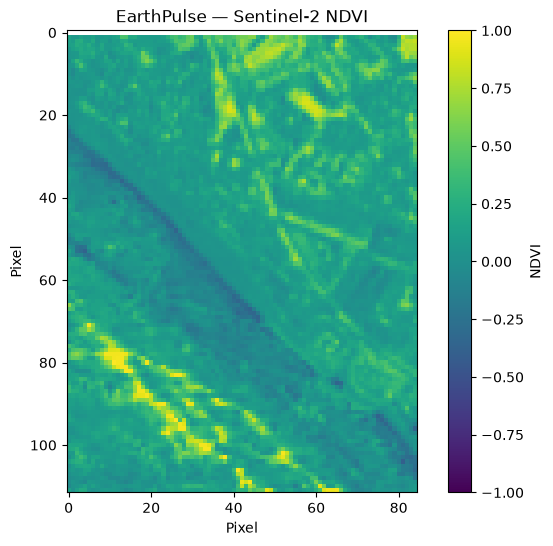

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(ndvi, vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("EarthPulse — Sentinel-2 NDVI")
plt.xlabel("Pixel")
plt.ylabel("Pixel")

plt.show()


In [24]:
print("NDVI minimo:", np.nanmin(ndvi))
print("NDVI massimo:", np.nanmax(ndvi))
print("NDVI medio:", np.nanmean(ndvi))
print("Pixel totali:", ndvi.size)

NDVI minimo: -0.38790035
NDVI massimo: 1.0
NDVI medio: 0.14828761
Pixel totali: 9520


In [25]:
# Distribuzione dei valori NDVI
percentili = np.nanpercentile(
    ndvi,
    [5, 25, 50, 75, 95]
)

print("Percentili NDVI:")
print("5% :", percentili[0])
print("25%:", percentili[1])
print("50%:", percentili[2])
print("75%:", percentili[3])
print("95%:", percentili[4])

Percentili NDVI:
5% : -0.10161958560347556
25%: 0.042825521901249886
50%: 0.1111111119389534
75%: 0.21198303252458572
95%: 0.5379703581333158


In [26]:
vegetation_threshold = 0.4

vegetated_pixels = np.sum(ndvi >= vegetation_threshold)
valid_pixels = np.sum(np.isfinite(ndvi))

vegetated_percentage = (
    vegetated_pixels / valid_pixels
) * 100

print(f"Pixel vegetati: {vegetated_pixels}")
print(f"Pixel validi: {valid_pixels}")
print(f"Area con NDVI >= {vegetation_threshold}: {vegetated_percentage:.1f}%")

Pixel vegetati: 911
Pixel validi: 9435
Area con NDVI >= 0.4: 9.7%


In [27]:
# Maschera dei pixel validi
valid_mask = np.isfinite(ndvi)

# NDVI pulito
ndvi_clean = np.where(valid_mask, ndvi, np.nan)

print("Pixel totali:", ndvi_clean.size)
print("Pixel validi:", np.sum(np.isfinite(ndvi_clean)))
print("Pixel esclusi:", np.sum(~np.isfinite(ndvi_clean)))

Pixel totali: 9520
Pixel validi: 9435
Pixel esclusi: 85


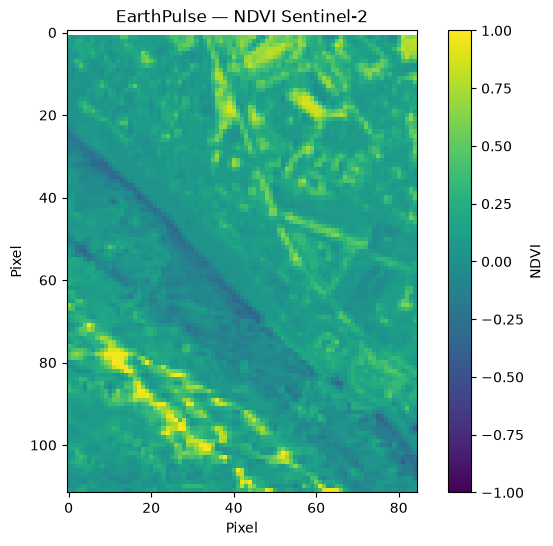

In [28]:
plt.figure(figsize=(8, 6))

plt.imshow(
    ndvi_clean,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDVI")
plt.title("EarthPulse — NDVI Sentinel-2")
plt.xlabel("Pixel")
plt.ylabel("Pixel")

plt.show()

In [29]:
# Cerchiamo tutte le immagini Sentinel-2 L2A
# disponibili sulla stessa AOI nel periodo scelto.

search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi_geometry,
    datetime="2025-06-01/2025-09-01",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = list(search.items())

print("Immagini trovate:", len(items))

Immagini trovate: 21


In [30]:
# Ordiniamo le immagini per data
items = sorted(items, key=lambda item: item.datetime)

for item in items:
    print(
        item.datetime.strftime("%Y-%m-%d"),
        "| cloud:",
        round(item.properties.get("eo:cloud_cover", 100), 2),
        "|",
        item.id
    )

2025-06-05 | cloud: 1.78 | S2C_33TVF_20250605_0_L2A
2025-06-07 | cloud: 0.01 | S2A_33TVF_20250607_1_L2A
2025-06-10 | cloud: 2.47 | S2B_33TVF_20250610_0_L2A
2025-06-15 | cloud: 0.58 | S2C_33TVF_20250615_0_L2A
2025-06-17 | cloud: 12.62 | S2A_33TVF_20250617_0_L2A
2025-06-20 | cloud: 1.51 | S2B_33TVF_20250620_1_L2A
2025-06-25 | cloud: 0.96 | S2C_33TVF_20250625_0_L2A
2025-06-27 | cloud: 0.27 | S2A_33TVF_20250627_0_L2A
2025-06-30 | cloud: 1.19 | S2B_33TVF_20250630_0_L2A
2025-07-05 | cloud: 1.65 | S2C_33TVF_20250705_0_L2A
2025-07-15 | cloud: 10.69 | S2C_33TVF_20250715_0_L2A
2025-07-17 | cloud: 12.39 | S2A_33TVF_20250717_0_L2A
2025-07-20 | cloud: 9.7 | S2B_33TVF_20250720_0_L2A
2025-07-25 | cloud: 14.86 | S2C_33TVF_20250725_0_L2A
2025-07-27 | cloud: 8.6 | S2A_33TVF_20250727_0_L2A
2025-07-30 | cloud: 16.94 | S2B_33TVF_20250730_0_L2A
2025-08-06 | cloud: 0.03 | S2A_33TVF_20250806_0_L2A
2025-08-09 | cloud: 0.01 | S2B_33TVF_20250809_0_L2A
2025-08-19 | cloud: 2.91 | S2B_33TVF_20250819_0_L2A
2025-08-2

In [40]:
import numpy as np
import pandas as pd
import rasterio

from rasterio.mask import mask
from rasterio.warp import reproject, Resampling


def calculate_ndvi_for_item(item, aoi):
    """
    Calcola NDVI medio e mediano su un'AOI usando Sentinel-2 L2A.

    B04 = RED 10 m
    B08 = NIR 10 m
    SCL = Scene Classification Layer 20 m

    La SCL viene ricampionata sulla griglia 10 m di B04/B08
    usando nearest-neighbor.
    """

    # ---------------------------------------------------------
    # 1. Recuperiamo gli URL degli asset
    # ---------------------------------------------------------

    red_url = item.assets["red"].href
    nir_url = item.assets["nir"].href
    scl_url = item.assets["scl"].href

    # ---------------------------------------------------------
    # 2. Apriamo RED e definiamo la griglia di riferimento
    # ---------------------------------------------------------

    with rasterio.open(red_url) as src_red:

        raster_crs = src_red.crs

        # Trasformiamo l'AOI nel CRS del raster
        aoi_utm = aoi.to_crs(raster_crs)

        geometry = aoi_utm.geometry.iloc[0].__geo_interface__

        # Crop RED
        red_aoi, red_transform = mask(
            src_red,
            [geometry],
            crop=True
        )

        red_crs = src_red.crs

    # ---------------------------------------------------------
    # 3. Crop NIR
    # ---------------------------------------------------------

    with rasterio.open(nir_url) as src_nir:

        nir_aoi, nir_transform = mask(
            src_nir,
            [geometry],
            crop=True
        )

    # Controllo fondamentale
    if red_aoi.shape != nir_aoi.shape:
        raise ValueError(
            f"RED e NIR hanno dimensioni diverse: "
            f"{red_aoi.shape} vs {nir_aoi.shape}"
        )

    # ---------------------------------------------------------
    # 4. Convertiamo RED e NIR in float
    # ---------------------------------------------------------

    red = red_aoi[0].astype("float32")
    nir = nir_aoi[0].astype("float32")

    # ---------------------------------------------------------
    # 5. Calcoliamo NDVI
    # ---------------------------------------------------------

    denominator = nir + red

    ndvi = np.full(
        red.shape,
        np.nan,
        dtype="float32"
    )

    valid_denominator = denominator != 0

    ndvi[valid_denominator] = (
        (nir[valid_denominator] - red[valid_denominator])
        / denominator[valid_denominator]
    )

    # ---------------------------------------------------------
    # 6. Leggiamo SCL
    # ---------------------------------------------------------

    with rasterio.open(scl_url) as src_scl:

        scl = np.empty(
            red.shape,
            dtype="uint8"
        )

        # Ricampioniamo SCL 20 m → griglia RED 10 m
        reproject(
            source=rasterio.band(src_scl, 1),
            destination=scl,
            src_transform=src_scl.transform,
            src_crs=src_scl.crs,
            dst_transform=red_transform,
            dst_crs=red_crs,
            resampling=Resampling.nearest
        )

    # ---------------------------------------------------------
    # 7. Classi SCL che consideriamo non valide
    # ---------------------------------------------------------

    invalid_scl_classes = [
        0,   # No data
        1,   # Saturated / defective
        3,   # Cloud shadow
        7,   # Unclassified
        8,   # Cloud medium probability
        9,   # Cloud high probability
        10,  # Thin cirrus
        11   # Snow / ice
    ]

    scl_valid = ~np.isin(
        scl,
        invalid_scl_classes
    )

    # ---------------------------------------------------------
    # 8. Combiniamo validità NDVI + SCL
    # ---------------------------------------------------------

    valid_mask = (
        np.isfinite(ndvi)
        & scl_valid
    )

    # ---------------------------------------------------------
    # 9. Applichiamo la maschera
    # ---------------------------------------------------------

    ndvi_clean = ndvi[valid_mask]

    # Se non rimangono pixel validi
    if len(ndvi_clean) == 0:
        return {
            "date": item.datetime,
            "item_id": item.id,
            "cloud_cover": item.properties.get("eo:cloud_cover"),
            "ndvi_mean": np.nan,
            "ndvi_median": np.nan,
            "valid_pixels": 0,
            "valid_percentage": 0.0
        }

    # ---------------------------------------------------------
    # 10. Statistiche
    # ---------------------------------------------------------

    total_pixels = ndvi.size
    valid_pixels = len(ndvi_clean)

    return {
        "date": item.datetime,
        "item_id": item.id,
        "cloud_cover": item.properties.get("eo:cloud_cover"),
        "ndvi_mean": float(np.mean(ndvi_clean)),
        "ndvi_median": float(np.median(ndvi_clean)),
        "valid_pixels": int(valid_pixels),
        "valid_percentage": float(
            valid_pixels / total_pixels * 100
        )
    }

In [41]:
test_result_scl = calculate_ndvi_for_item(
    items[0],
    aoi
)

test_result_scl

{'date': datetime.datetime(2025, 6, 5, 9, 59, 42, 626000, tzinfo=tzutc()),
 'item_id': 'S2C_33TVF_20250605_0_L2A',
 'cloud_cover': 1.780369,
 'ndvi_mean': 0.32256606221199036,
 'ndvi_median': 0.2272506058216095,
 'valid_pixels': 9419,
 'valid_percentage': 98.9390756302521}

In [42]:
results_scl = []

for i, item in enumerate(items, start=1):

    print(
        f"[{i}/{len(items)}] "
        f"{item.datetime.strftime('%Y-%m-%d')}"
    )

    result = calculate_ndvi_for_item(
        item,
        aoi
    )

    results_scl.append(result)


ndvi_timeseries_scl = pd.DataFrame(
    results_scl
)

ndvi_timeseries_scl = (
    ndvi_timeseries_scl
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nElaborazione completata.")

ndvi_timeseries_scl

[1/21] 2025-06-05
[2/21] 2025-06-07
[3/21] 2025-06-10
[4/21] 2025-06-15
[5/21] 2025-06-17
[6/21] 2025-06-20
[7/21] 2025-06-25
[8/21] 2025-06-27
[9/21] 2025-06-30
[10/21] 2025-07-05
[11/21] 2025-07-15
[12/21] 2025-07-17
[13/21] 2025-07-20
[14/21] 2025-07-25
[15/21] 2025-07-27
[16/21] 2025-07-30
[17/21] 2025-08-06
[18/21] 2025-08-09
[19/21] 2025-08-19
[20/21] 2025-08-24
[21/21] 2025-08-26

Elaborazione completata.


,date,item_id,cloud_cover,ndvi_mean,ndvi_median,valid_pixels,valid_percentage
0,2025-06-05 09:59:42.626000+00:00,S2C_33TVF_20250605_0_L2A,1.780369,0.322566,0.227251,9419,98.939076
1,2025-06-07 09:59:42.616000+00:00,S2A_33TVF_20250607_1_L2A,0.008523,0.148288,0.111111,9435,99.107143
2,2025-06-10 09:59:20.628000+00:00,S2B_33TVF_20250610_0_L2A,2.473024,0.095345,0.057348,9435,99.107143
3,2025-06-15 09:59:41.347000+00:00,S2C_33TVF_20250615_0_L2A,0.584597,0.059860,0.059540,9435,99.107143
4,2025-06-17 09:59:35.269000+00:00,S2A_33TVF_20250617_0_L2A,12.618899,0.074984,0.053347,9435,99.107143
5,2025-06-20 09:59:22.795000+00:00,S2B_33TVF_20250620_1_L2A,1.505549,0.075587,0.061548,9435,99.107143
6,2025-06-25 09:59:42.231000+00:00,S2C_33TVF_20250625_0_L2A,0.961370,0.055700,0.056579,9435,99.107143
7,2025-06-27 09:59:38.215000+00:00,S2A_33TVF_20250627_0_L2A,0.266356,0.076414,0.059829,9435,99.107143
8,2025-06-30 09:59:24.882000+00:00,S2B_33TVF_20250630_0_L2A,1.190165,0.001492,0.047120,9435,99.107143
9,2025-07-05 09:59:44.582000+00:00,S2C_33TVF_20250705_0_L2A,1.651202,0.057870,0.047101,9435,99.107143


In [43]:
comparison = ndvi_timeseries[
    ["date", "ndvi_mean"]
].merge(
    ndvi_timeseries_scl[
        ["date", "ndvi_mean", "valid_percentage"]
    ],
    on="date",
    suffixes=("_no_scl", "_scl")
)

comparison

ValueError: You are trying to merge on object and datetime64[us, tzutc()] columns for key 'date'. If you wish to proceed you should use pd.concat

In [44]:
# Convertiamo entrambe le colonne date nello stesso formato
ndvi_timeseries["date"] = pd.to_datetime(
    ndvi_timeseries["date"],
    utc=True
)

ndvi_timeseries_scl["date"] = pd.to_datetime(
    ndvi_timeseries_scl["date"],
    utc=True
)

# Controllo
print("Tipo date senza SCL:", ndvi_timeseries["date"].dtype)
print("Tipo date con SCL:", ndvi_timeseries_scl["date"].dtype)

Tipo date senza SCL: datetime64[s, UTC]
Tipo date con SCL: datetime64[us, UTC]


In [45]:
comparison = ndvi_timeseries[
    ["date", "ndvi_mean"]
].merge(
    ndvi_timeseries_scl[
        ["date", "ndvi_mean", "valid_percentage"]
    ],
    on="date",
    suffixes=("_no_scl", "_scl")
)

comparison

,date,ndvi_mean_no_scl,ndvi_mean_scl,valid_percentage


In [46]:
comparison["ndvi_difference"] = (
    comparison["ndvi_mean_scl"]
    - comparison["ndvi_mean_no_scl"]
)

comparison[
    [
        "date",
        "ndvi_mean_no_scl",
        "ndvi_mean_scl",
        "ndvi_difference",
        "valid_percentage"
    ]
]

,date,ndvi_mean_no_scl,ndvi_mean_scl,ndvi_difference,valid_percentage


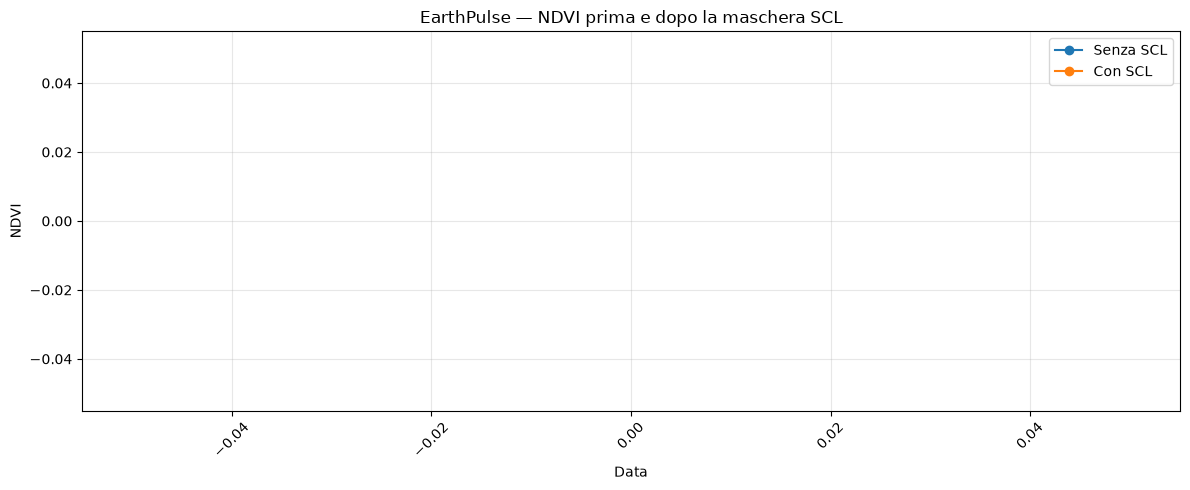

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison["date"],
    comparison["ndvi_mean_no_scl"],
    marker="o",
    label="Senza SCL"
)

plt.plot(
    comparison["date"],
    comparison["ndvi_mean_scl"],
    marker="o",
    label="Con SCL"
)

plt.title(
    "EarthPulse — NDVI prima e dopo la maschera SCL"
)

plt.xlabel("Data")
plt.ylabel("NDVI")

plt.grid(True, alpha=0.3)
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [48]:
print(
    f"Pixel validi medi: "
    f"{ndvi_timeseries_scl['valid_percentage'].mean():.1f}%"
)

print(
    f"Pixel validi minimi: "
    f"{ndvi_timeseries_scl['valid_percentage'].min():.1f}%"
)

print(
    f"Pixel validi massimi: "
    f"{ndvi_timeseries_scl['valid_percentage'].max():.1f}%"
)

Pixel validi medi: 87.8%
Pixel validi minimi: 0.0%
Pixel validi massimi: 99.1%


In [49]:
low_quality = ndvi_timeseries_scl[
    ndvi_timeseries_scl["valid_percentage"] < 70
]

print(
    f"Osservazioni con meno del 70% di pixel validi: "
    f"{len(low_quality)}"
)

low_quality[
    [
        "date",
        "cloud_cover",
        "ndvi_mean",
        "valid_percentage"
    ]
]

Osservazioni con meno del 70% di pixel validi: 3


,date,cloud_cover,ndvi_mean,valid_percentage
12,2025-07-20 09:59:24.899000+00:00,9.699713,NaN,0.00000
13,2025-07-25 09:59:44.659000+00:00,14.858730,NaN,0.00000
14,2025-07-27 09:59:40.655000+00:00,8.603601,-0.018633,61.37605


In [50]:
print(comparison.dtypes)
print()
print(comparison)

date                datetime64[s, UTC]
ndvi_mean_no_scl               float32
ndvi_mean_scl                  float64
valid_percentage               float64
ndvi_difference                float64
dtype: object

Empty DataFrame
Columns: [date, ndvi_mean_no_scl, ndvi_mean_scl, valid_percentage, ndvi_difference]
Index: []


In [51]:
print("NDVI senza SCL validi:",
      comparison["ndvi_mean_no_scl"].notna().sum())

print("NDVI con SCL validi:",
      comparison["ndvi_mean_scl"].notna().sum())

print("Date totali:",
      len(comparison))

NDVI senza SCL validi: 0
NDVI con SCL validi: 0
Date totali: 0


In [54]:
from collections import Counter

item_test = items[12]  # 20 luglio 2025

scl_url = item_test.assets["scl"].href
red_url = item_test.assets["red"].href

# CRS del RED
with rasterio.open(red_url) as src_red:
    raster_crs = src_red.crs

aoi_utm = aoi.to_crs(raster_crs)
geometry = aoi_utm.geometry.iloc[0].__geo_interface__

# Leggiamo direttamente la SCL sull'AOI
with rasterio.open(scl_url) as src_scl:
    scl_aoi, scl_transform = mask(
        src_scl,
        [geometry],
        crop=True
    )

scl_values = scl_aoi[0]

# Conteggio delle classi
classes, counts = np.unique(
    scl_values,
    return_counts=True
)

print("Data:", item_test.datetime)
print()
print("Classi SCL trovate:")

for cls, count in zip(classes, counts):
    percentage = count / scl_values.size * 100
    print(
        f"Classe {cls}: "
        f"{count} pixel "
        f"({percentage:.1f}%)"
    )

Data: 2025-07-20 09:59:24.899000+00:00

Classi SCL trovate:
Classe 0: 56 pixel (2.3%)
Classe 8: 396 pixel (16.4%)
Classe 9: 1956 pixel (81.2%)


In [55]:
from collections import Counter

item_test = items[13]  # 20 luglio 2025

scl_url = item_test.assets["scl"].href
red_url = item_test.assets["red"].href

# CRS del RED
with rasterio.open(red_url) as src_red:
    raster_crs = src_red.crs

aoi_utm = aoi.to_crs(raster_crs)
geometry = aoi_utm.geometry.iloc[0].__geo_interface__

# Leggiamo direttamente la SCL sull'AOI
with rasterio.open(scl_url) as src_scl:
    scl_aoi, scl_transform = mask(
        src_scl,
        [geometry],
        crop=True
    )

scl_values = scl_aoi[0]

# Conteggio delle classi
classes, counts = np.unique(
    scl_values,
    return_counts=True
)

print("Data:", item_test.datetime)
print()
print("Classi SCL trovate:")

for cls, count in zip(classes, counts):
    percentage = count / scl_values.size * 100
    print(
        f"Classe {cls}: "
        f"{count} pixel "
        f"({percentage:.1f}%)"
    )

Data: 2025-07-25 09:59:44.659000+00:00

Classi SCL trovate:
Classe 0: 56 pixel (2.3%)
Classe 8: 351 pixel (14.6%)
Classe 9: 1983 pixel (82.4%)
Classe 10: 18 pixel (0.7%)


In [56]:
from collections import Counter

item_test = items[14]  # 20 luglio 2025

scl_url = item_test.assets["scl"].href
red_url = item_test.assets["red"].href

# CRS del RED
with rasterio.open(red_url) as src_red:
    raster_crs = src_red.crs

aoi_utm = aoi.to_crs(raster_crs)
geometry = aoi_utm.geometry.iloc[0].__geo_interface__

# Leggiamo direttamente la SCL sull'AOI
with rasterio.open(scl_url) as src_scl:
    scl_aoi, scl_transform = mask(
        src_scl,
        [geometry],
        crop=True
    )

scl_values = scl_aoi[0]

# Conteggio delle classi
classes, counts = np.unique(
    scl_values,
    return_counts=True
)

print("Data:", item_test.datetime)
print()
print("Classi SCL trovate:")

for cls, count in zip(classes, counts):
    percentage = count / scl_values.size * 100
    print(
        f"Classe {cls}: "
        f"{count} pixel "
        f"({percentage:.1f}%)"
    )

Data: 2025-07-27 09:59:40.655000+00:00

Classi SCL trovate:
Classe 0: 56 pixel (2.3%)
Classe 3: 44 pixel (1.8%)
Classe 4: 4 pixel (0.2%)
Classe 5: 526 pixel (21.8%)
Classe 6: 918 pixel (38.1%)
Classe 7: 108 pixel (4.5%)
Classe 8: 244 pixel (10.1%)
Classe 9: 508 pixel (21.1%)


In [57]:
ndvi_timeseries_scl = ndvi_timeseries_scl[
    ndvi_timeseries_scl["valid_percentage"] > 70
]

In [58]:
print(comparison)

Empty DataFrame
Columns: [date, ndvi_mean_no_scl, ndvi_mean_scl, valid_percentage, ndvi_difference]
Index: []


In [59]:
# Copie per non modificare accidentalmente i DataFrame originali
raw_compare = ndvi_timeseries.copy()
scl_compare = ndvi_timeseries_scl.copy()

# Convertiamo le date
raw_compare["date"] = pd.to_datetime(
    raw_compare["date"],
    utc=True
)

scl_compare["date"] = pd.to_datetime(
    scl_compare["date"],
    utc=True
)

# Creiamo una data senza ora
raw_compare["date_only"] = (
    raw_compare["date"]
    .dt.tz_convert("UTC")
    .dt.date
)

scl_compare["date_only"] = (
    scl_compare["date"]
    .dt.tz_convert("UTC")
    .dt.date
)

# Controllo
print("Prime date senza SCL:")
print(raw_compare["date_only"].head())

print("\nPrime date con SCL:")
print(scl_compare["date_only"].head())

Prime date senza SCL:
0    2025-06-05
1    2025-06-07
2    2025-06-10
3    2025-06-15
4    2025-06-17
Name: date_only, dtype: object

Prime date con SCL:
0    2025-06-05
1    2025-06-07
2    2025-06-10
3    2025-06-15
4    2025-06-17
Name: date_only, dtype: object


In [60]:
comparison = raw_compare[
    ["date_only", "ndvi_mean"]
].merge(
    scl_compare[
        ["date_only", "ndvi_mean", "valid_percentage"]
    ],
    on="date_only",
    suffixes=("_no_scl", "_scl"),
    how="inner"
)

comparison["ndvi_difference"] = (
    comparison["ndvi_mean_scl"]
    - comparison["ndvi_mean_no_scl"]
)

comparison

,date_only,ndvi_mean_no_scl,ndvi_mean_scl,valid_percentage,ndvi_difference
0,2025-06-05,0.321457,0.322566,98.939076,0.001109
1,2025-06-07,0.148288,0.148288,99.107143,0.000000
2,2025-06-10,0.095345,0.095345,99.107143,0.000000
3,2025-06-15,0.059860,0.059860,99.107143,0.000000
4,2025-06-17,0.074984,0.074984,99.107143,0.000000
5,2025-06-20,0.075587,0.075587,99.107143,0.000000
6,2025-06-25,0.055700,0.055700,99.107143,0.000000
7,2025-06-27,0.076414,0.076414,99.107143,0.000000
8,2025-06-30,0.001492,0.001492,99.107143,0.000000
9,2025-07-05,0.057870,0.057870,99.107143,0.000000


In [61]:
def classify_quality(valid_percentage):

    if valid_percentage >= 80:
        return "Good"

    elif valid_percentage >= 50:
        return "Acceptable"

    else:
        return "Poor"


ndvi_timeseries_scl["quality"] = (
    ndvi_timeseries_scl["valid_percentage"]
    .apply(classify_quality)
)

ndvi_timeseries_scl[
    [
        "date",
        "cloud_cover",
        "ndvi_mean",
        "valid_percentage",
        "quality"
    ]
]

,date,cloud_cover,ndvi_mean,valid_percentage,quality
0,2025-06-05 09:59:42.626000+00:00,1.780369,0.322566,98.939076,Good
1,2025-06-07 09:59:42.616000+00:00,0.008523,0.148288,99.107143,Good
2,2025-06-10 09:59:20.628000+00:00,2.473024,0.095345,99.107143,Good
3,2025-06-15 09:59:41.347000+00:00,0.584597,0.059860,99.107143,Good
4,2025-06-17 09:59:35.269000+00:00,12.618899,0.074984,99.107143,Good
5,2025-06-20 09:59:22.795000+00:00,1.505549,0.075587,99.107143,Good
6,2025-06-25 09:59:42.231000+00:00,0.961370,0.055700,99.107143,Good
7,2025-06-27 09:59:38.215000+00:00,0.266356,0.076414,99.107143,Good
8,2025-06-30 09:59:24.882000+00:00,1.190165,0.001492,99.107143,Good
9,2025-07-05 09:59:44.582000+00:00,1.651202,0.057870,99.107143,Good


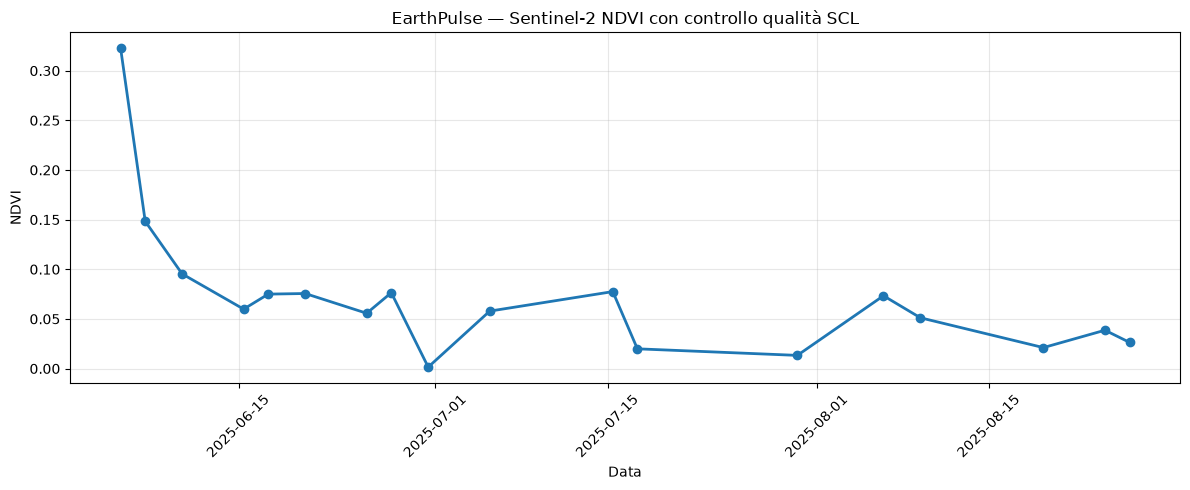

In [62]:
plot_df = ndvi_timeseries_scl[
    ndvi_timeseries_scl["valid_percentage"] >= 50
].copy()

plot_df = plot_df.sort_values("date")

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["ndvi_mean"],
    marker="o",
    linewidth=2
)

plt.title(
    "EarthPulse — Sentinel-2 NDVI con controllo qualità SCL"
)

plt.xlabel("Data")
plt.ylabel("NDVI")

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

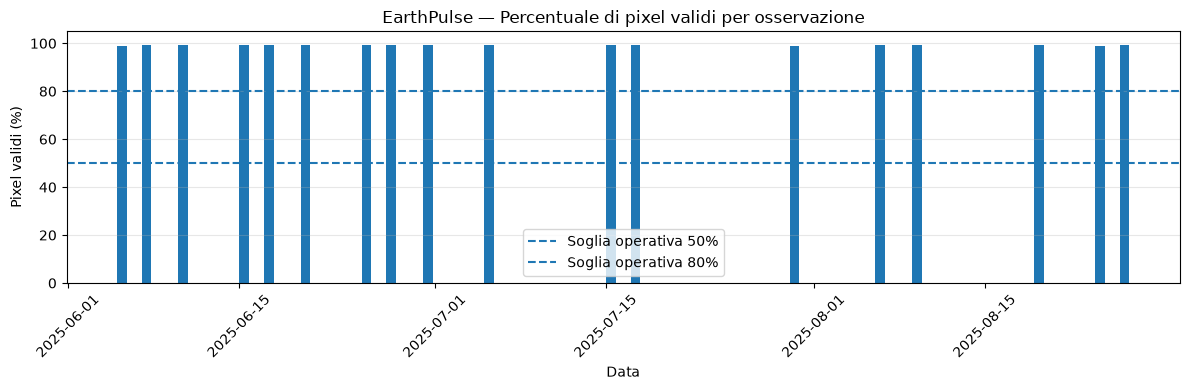

In [63]:
plt.figure(figsize=(12, 4))

plt.bar(
    ndvi_timeseries_scl["date"],
    ndvi_timeseries_scl["valid_percentage"]
)

plt.axhline(
    50,
    linestyle="--",
    label="Soglia operativa 50%"
)

plt.axhline(
    80,
    linestyle="--",
    label="Soglia operativa 80%"
)

plt.title(
    "EarthPulse — Percentuale di pixel validi per osservazione"
)

plt.xlabel("Data")
plt.ylabel("Pixel validi (%)")

plt.ylim(0, 105)

plt.grid(True, axis="y", alpha=0.3)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [64]:
# Serie temporale utilizzabile per le analisi
analysis_df = ndvi_timeseries_scl.copy()

analysis_df["date"] = pd.to_datetime(
    analysis_df["date"],
    utc=True
)

# Manteniamo le osservazioni con almeno il 50% di pixel validi
analysis_df = analysis_df[
    analysis_df["valid_percentage"] >= 50
].copy()

analysis_df = (
    analysis_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Osservazioni totali:", len(ndvi_timeseries_scl))
print("Osservazioni utilizzabili:", len(analysis_df))

analysis_df[
    [
        "date",
        "ndvi_mean",
        "ndvi_median",
        "valid_percentage",
        "quality"
    ]
]

Osservazioni totali: 18
Osservazioni utilizzabili: 18


,date,ndvi_mean,ndvi_median,valid_percentage,quality
0,2025-06-05 09:59:42.626000+00:00,0.322566,0.227251,98.939076,Good
1,2025-06-07 09:59:42.616000+00:00,0.148288,0.111111,99.107143,Good
2,2025-06-10 09:59:20.628000+00:00,0.095345,0.057348,99.107143,Good
3,2025-06-15 09:59:41.347000+00:00,0.059860,0.059540,99.107143,Good
4,2025-06-17 09:59:35.269000+00:00,0.074984,0.053347,99.107143,Good
5,2025-06-20 09:59:22.795000+00:00,0.075587,0.061548,99.107143,Good
6,2025-06-25 09:59:42.231000+00:00,0.055700,0.056579,99.107143,Good
7,2025-06-27 09:59:38.215000+00:00,0.076414,0.059829,99.107143,Good
8,2025-06-30 09:59:24.882000+00:00,0.001492,0.047120,99.107143,Good
9,2025-07-05 09:59:44.582000+00:00,0.057870,0.047101,99.107143,Good


In [66]:
print("Statistiche NDVI osservazioni utilizzabili")
print("------------------------------------------")

print(
    f"Media:   {analysis_df['ndvi_mean'].mean():.4f}"
)

print(
    f"Mediana: {analysis_df['ndvi_mean'].median():.4f}"
)

print(
    f"Minimo:  {analysis_df['ndvi_mean'].min():.4f}"
)

print(
    f"Massimo: {analysis_df['ndvi_mean'].max():.4f}"
)

print(
    f"Deviazione standard: "
    f"{analysis_df['ndvi_mean'].std():.4f}"
)

Statistiche NDVI osservazioni utilizzabili
------------------------------------------
Media:   0.0716
Mediana: 0.0589
Minimo:  0.0015
Massimo: 0.3226
Deviazione standard: 0.0716


In [67]:
baseline_ndvi = analysis_df["ndvi_mean"].median()

print(
    f"Baseline NDVI: {baseline_ndvi:.4f}"
)

Baseline NDVI: 0.0589


In [68]:
analysis_df["ndvi_anomaly"] = (
    analysis_df["ndvi_mean"]
    - baseline_ndvi
)

analysis_df["ndvi_anomaly_pct"] = (
    analysis_df["ndvi_anomaly"]
    / baseline_ndvi
) * 100

analysis_df[
    [
        "date",
        "ndvi_mean",
        "ndvi_anomaly",
        "ndvi_anomaly_pct"
    ]
]

,date,ndvi_mean,ndvi_anomaly,ndvi_anomaly_pct
0,2025-06-05 09:59:42.626000+00:00,0.322566,0.263701,447.976802
1,2025-06-07 09:59:42.616000+00:00,0.148288,0.089423,151.911715
2,2025-06-10 09:59:20.628000+00:00,0.095345,0.036480,61.972067
3,2025-06-15 09:59:41.347000+00:00,0.059860,0.000995,1.690477
4,2025-06-17 09:59:35.269000+00:00,0.074984,0.016119,27.383083
5,2025-06-20 09:59:22.795000+00:00,0.075587,0.016722,28.407775
6,2025-06-25 09:59:42.231000+00:00,0.055700,-0.003165,-5.376118
7,2025-06-27 09:59:38.215000+00:00,0.076414,0.017549,29.811774
8,2025-06-30 09:59:24.882000+00:00,0.001492,-0.057373,-97.465453
9,2025-07-05 09:59:44.582000+00:00,0.057870,-0.000995,-1.690477


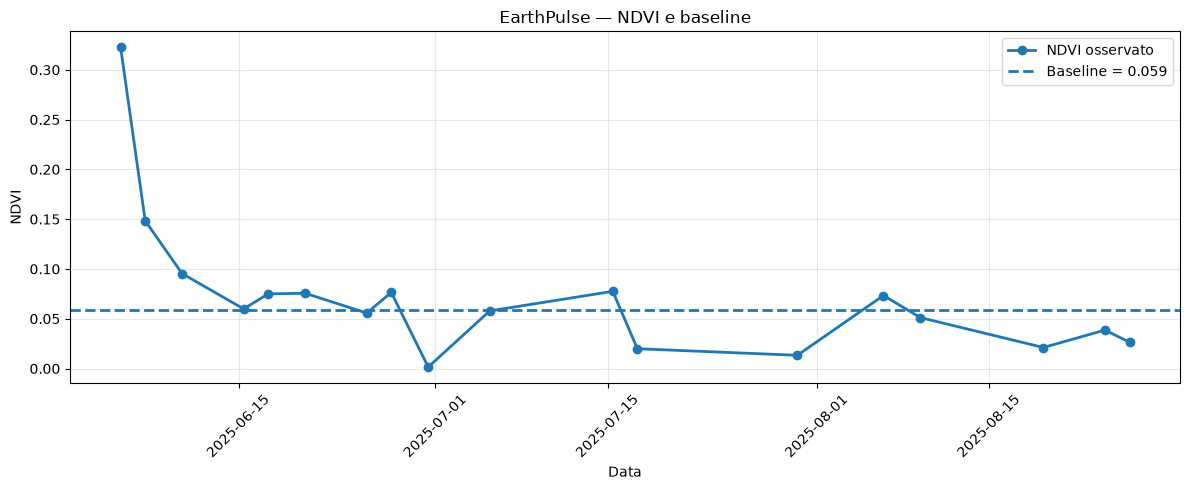

In [69]:
plt.figure(figsize=(12, 5))

plt.plot(
    analysis_df["date"],
    analysis_df["ndvi_mean"],
    marker="o",
    linewidth=2,
    label="NDVI osservato"
)

plt.axhline(
    baseline_ndvi,
    linestyle="--",
    linewidth=2,
    label=f"Baseline = {baseline_ndvi:.3f}"
)

plt.title(
    "EarthPulse — NDVI e baseline"
)

plt.xlabel("Data")
plt.ylabel("NDVI")

plt.grid(True, alpha=0.3)
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [70]:
def classify_anomaly(anomaly_pct):
    
    if anomaly_pct <= -20:
        return "Decrease"
    
    elif anomaly_pct >= 20:
        return "Increase"
    
    else:
        return "Stable"


analysis_df["status"] = (
    analysis_df["ndvi_anomaly_pct"]
    .apply(classify_anomaly)
)

analysis_df[
    [
        "date",
        "ndvi_mean",
        "ndvi_anomaly_pct",
        "status"
    ]
]

,date,ndvi_mean,ndvi_anomaly_pct,status
0,2025-06-05 09:59:42.626000+00:00,0.322566,447.976802,Increase
1,2025-06-07 09:59:42.616000+00:00,0.148288,151.911715,Increase
2,2025-06-10 09:59:20.628000+00:00,0.095345,61.972067,Increase
3,2025-06-15 09:59:41.347000+00:00,0.059860,1.690477,Stable
4,2025-06-17 09:59:35.269000+00:00,0.074984,27.383083,Increase
5,2025-06-20 09:59:22.795000+00:00,0.075587,28.407775,Increase
6,2025-06-25 09:59:42.231000+00:00,0.055700,-5.376118,Stable
7,2025-06-27 09:59:38.215000+00:00,0.076414,29.811774,Increase
8,2025-06-30 09:59:24.882000+00:00,0.001492,-97.465453,Decrease
9,2025-07-05 09:59:44.582000+00:00,0.057870,-1.690477,Stable


In [71]:
print(
    analysis_df["status"]
    .value_counts()
)

status
Increase    8
Decrease    6
Stable      4
Name: count, dtype: int64


In [72]:
analysis_df[
    [
        "date",
        "ndvi_mean",
        "valid_percentage",
        "quality"
    ]
].to_string(index=False)

'                            date  ndvi_mean  valid_percentage quality\n2025-06-05 09:59:42.626000+00:00   0.322566         98.939076    Good\n2025-06-07 09:59:42.616000+00:00   0.148288         99.107143    Good\n2025-06-10 09:59:20.628000+00:00   0.095345         99.107143    Good\n2025-06-15 09:59:41.347000+00:00   0.059860         99.107143    Good\n2025-06-17 09:59:35.269000+00:00   0.074984         99.107143    Good\n2025-06-20 09:59:22.795000+00:00   0.075587         99.107143    Good\n2025-06-25 09:59:42.231000+00:00   0.055700         99.107143    Good\n2025-06-27 09:59:38.215000+00:00   0.076414         99.107143    Good\n2025-06-30 09:59:24.882000+00:00   0.001492         99.107143    Good\n2025-07-05 09:59:44.582000+00:00   0.057870         99.107143    Good\n2025-07-15 09:59:45.402000+00:00   0.077511         99.107143    Good\n2025-07-17 09:59:41.483000+00:00   0.019891         99.107143    Good\n2025-07-30 09:59:22.349000+00:00   0.013282         99.023109    Good\n2025-

In [73]:
print("Numero osservazioni:", len(analysis_df))

print(
    "\nNDVI mediano:",
    analysis_df["ndvi_mean"].median()
)

print(
    "NDVI medio:",
    analysis_df["ndvi_mean"].mean()
)

print(
    "NDVI minimo:",
    analysis_df["ndvi_mean"].min()
)

print(
    "NDVI massimo:",
    analysis_df["ndvi_mean"].max()
)

Numero osservazioni: 18

NDVI mediano: 0.058864912018179893
NDVI medio: 0.07163234812388611
NDVI minimo: 0.0014919586246833205
NDVI massimo: 0.32256606221199036


In [74]:
q1 = analysis_df["ndvi_mean"].quantile(0.25)
q3 = analysis_df["ndvi_mean"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1:.4f}")
print(f"Q3: {q3:.4f}")
print(f"IQR: {iqr:.4f}")

print(f"\nLimite inferiore: {lower_bound:.4f}")
print(f"Limite superiore: {upper_bound:.4f}")

print("\nPossibili outlier:")

analysis_df[
    (analysis_df["ndvi_mean"] < lower_bound) |
    (analysis_df["ndvi_mean"] > upper_bound)
][
    [
        "date",
        "ndvi_mean",
        "valid_percentage"
    ]
]

Q1: 0.0294
Q3: 0.0762
IQR: 0.0468

Limite inferiore: -0.0407
Limite superiore: 0.1464

Possibili outlier:


,date,ndvi_mean,valid_percentage
0,2025-06-05 09:59:42.626000+00:00,0.322566,98.939076
1,2025-06-07 09:59:42.616000+00:00,0.148288,99.107143


In [75]:
baseline_df = analysis_df[
    (analysis_df["ndvi_mean"] >= lower_bound) &
    (analysis_df["ndvi_mean"] <= upper_bound)
].copy()

robust_baseline = baseline_df["ndvi_mean"].median()

print(
    f"Baseline robusta provvisoria: "
    f"{robust_baseline:.4f}"
)

print(
    f"Osservazioni usate: "
    f"{len(baseline_df)} / {len(analysis_df)}"
)

Baseline robusta provvisoria: 0.0568
Osservazioni usate: 16 / 18


In [76]:
print(f"Baseline precedente: {baseline_ndvi:.4f}")
print(f"Baseline robusta:    {robust_baseline:.4f}")

difference = robust_baseline - baseline_ndvi

print(
    f"Differenza:          {difference:.4f}"
)

Baseline precedente: 0.0589
Baseline robusta:    0.0568
Differenza:          -0.0021


In [77]:
item_test = items[0]

print("ID:", item_test.id)
print("Data:", item_test.datetime)

scl_url = item_test.assets["scl"].href
red_url = item_test.assets["red"].href

with rasterio.open(red_url) as src_red:
    raster_crs = src_red.crs

aoi_utm = aoi.to_crs(raster_crs)
geometry = aoi_utm.geometry.iloc[0].__geo_interface__

with rasterio.open(scl_url) as src_scl:

    scl_aoi, scl_transform = mask(
        src_scl,
        [geometry],
        crop=True
    )

scl_values = scl_aoi[0]

classes, counts = np.unique(
    scl_values,
    return_counts=True
)

print("\nClassi SCL:")

for cls, count in zip(classes, counts):

    percentage = (
        count /
        scl_values.size *
        100
    )

    print(
        f"Classe {cls}: "
        f"{count} pixel "
        f"({percentage:.1f}%)"
    )

ID: S2C_33TVF_20250605_0_L2A
Data: 2025-06-05 09:59:42.626000+00:00

Classi SCL:
Classe 0: 56 pixel (2.3%)
Classe 4: 77 pixel (3.2%)
Classe 5: 1302 pixel (54.1%)
Classe 6: 969 pixel (40.2%)
Classe 10: 4 pixel (0.2%)


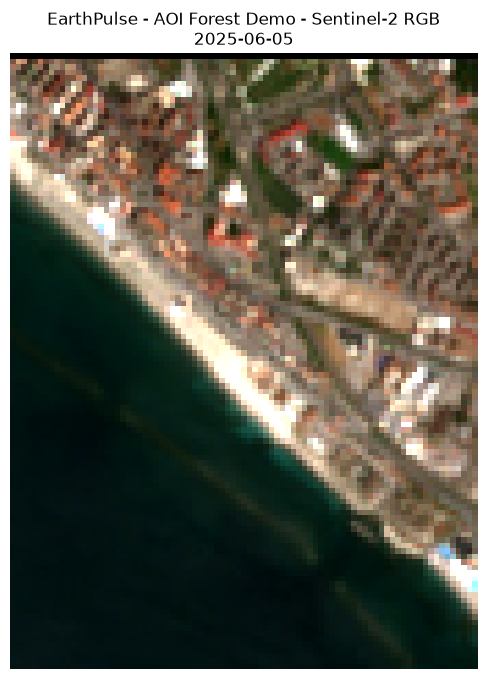

In [78]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask

# Prendiamo la scena del 5 giugno 2025
item = items[0]

# Asset RGB
blue_url = item.assets["blue"].href
green_url = item.assets["green"].href
red_url = item.assets["red"].href

# Usiamo il RED per ottenere CRS e geometria dell'AOI
with rasterio.open(red_url) as src:
    aoi_utm = aoi.to_crs(src.crs)
    geometry = aoi_utm.geometry.iloc[0].__geo_interface__

# Leggiamo le tre bande RGB
with rasterio.open(red_url) as src:
    red, transform = mask(src, [geometry], crop=True)

with rasterio.open(green_url) as src:
    green, _ = mask(src, [geometry], crop=True)

with rasterio.open(blue_url) as src:
    blue, _ = mask(src, [geometry], crop=True)

# Convertiamo in float
red = red[0].astype("float32")
green = green[0].astype("float32")
blue = blue[0].astype("float32")

# Creiamo RGB
rgb = np.dstack([red, green, blue])

# Normalizzazione semplice per visualizzazione
rgb_min = np.percentile(rgb, 2)
rgb_max = np.percentile(rgb, 98)

rgb_display = np.clip(
    (rgb - rgb_min) / (rgb_max - rgb_min),
    0,
    1
)

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title("EarthPulse - AOI Forest Demo - Sentinel-2 RGB\n2025-06-05")
plt.axis("off")
plt.show()

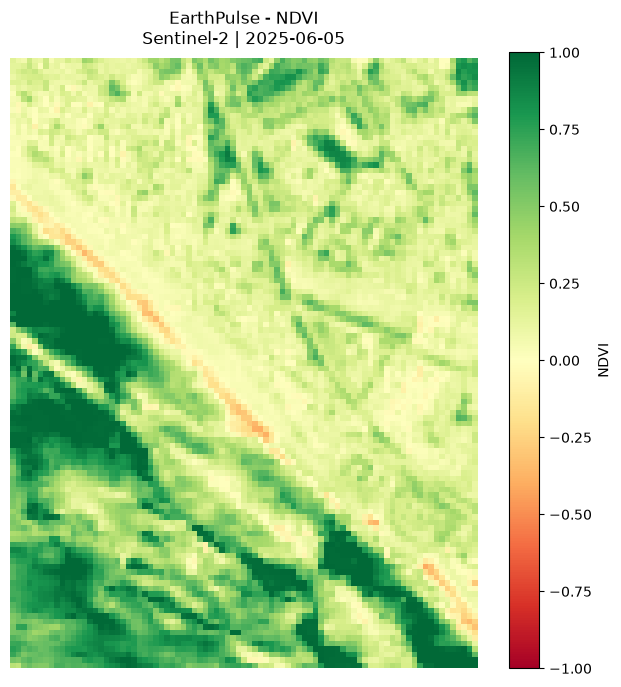

In [79]:
# Calcoliamo nuovamente NDVI per il 5 giugno
with rasterio.open(red_url) as src:
    red_aoi, transform = mask(src, [geometry], crop=True)

with rasterio.open(nir_url) as src:
    nir_aoi, _ = mask(src, [geometry], crop=True)

red = red_aoi[0].astype("float32")
nir = nir_aoi[0].astype("float32")

denominator = nir + red

ndvi = np.full(red.shape, np.nan, dtype="float32")

valid = denominator != 0

ndvi[valid] = (
    (nir[valid] - red[valid])
    / denominator[valid]
)

# Visualizzazione
plt.figure(figsize=(8, 8))

im = plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="NDVI")
plt.title("EarthPulse - NDVI\nSentinel-2 | 2025-06-05")
plt.axis("off")

plt.show()

CRS: EPSG:32633
Dimensioni: 10980 x 10980
Risoluzione: (10.0, 10.0)


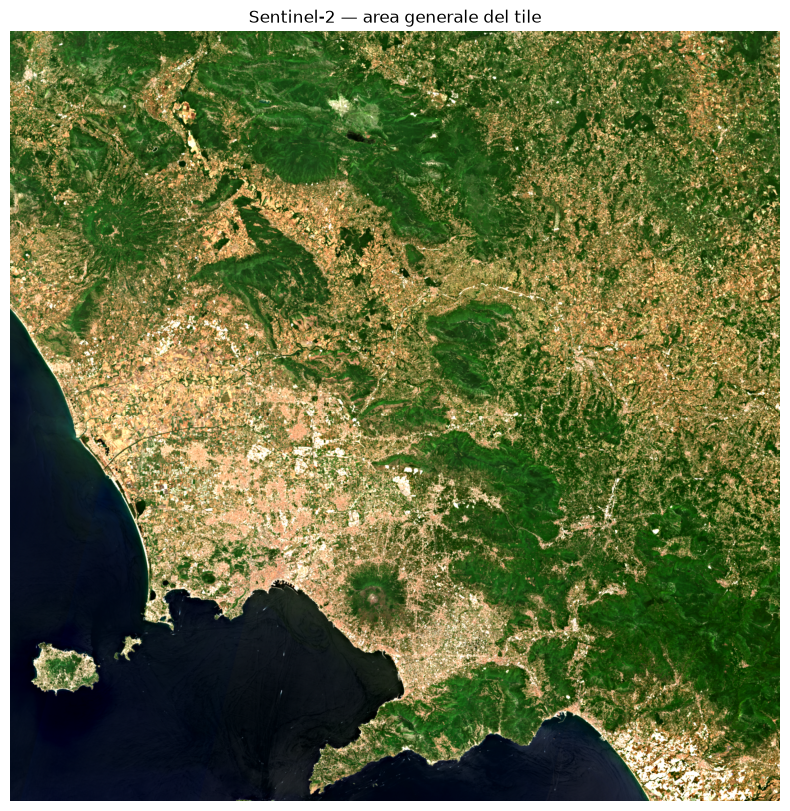

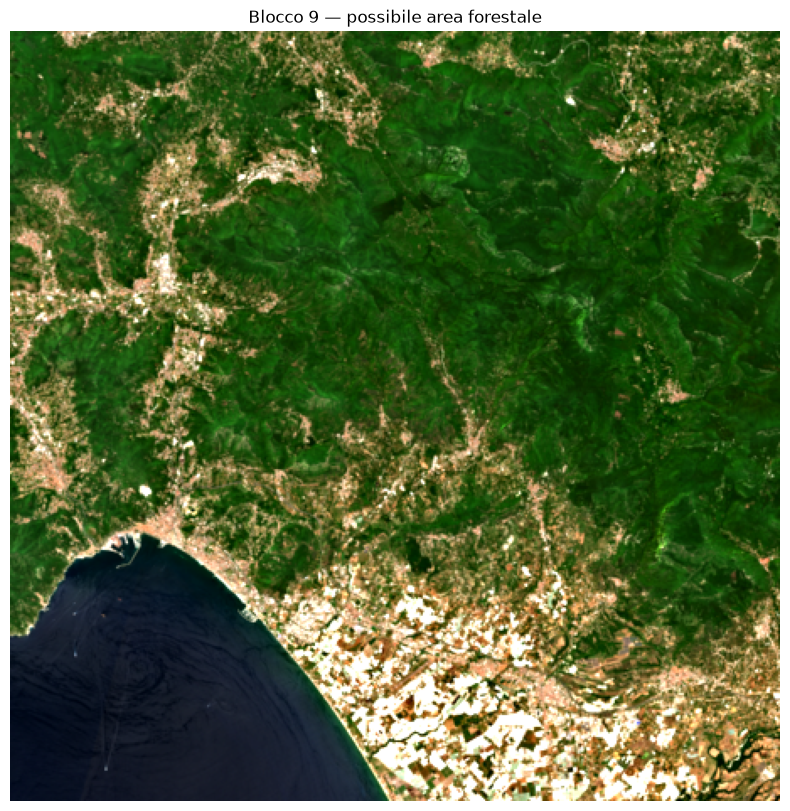

In [81]:
import matplotlib.pyplot as plt
import rasterio

item = items[0]

# Usiamo l'asset visual di Sentinel-2
visual_url = item.assets["visual"].href

with rasterio.open(visual_url) as src:
    print("CRS:", src.crs)
    print("Dimensioni:", src.width, "x", src.height)
    print("Risoluzione:", src.res)

    # Leggiamo una versione ridotta dell'immagine
    scale = 8

    rgb = src.read(
        out_shape=(
            3,
            src.height // scale,
            src.width // scale
        )
    )

# Portiamo i valori in 0-1
rgb = rgb.astype("float32")

rgb_min = np.percentile(rgb, 2)
rgb_max = np.percentile(rgb, 98)

rgb_display = np.clip(
    (rgb - rgb_min) / (rgb_max - rgb_min),
    0,
    1
)

plt.figure(figsize=(12, 10))
plt.imshow(np.moveaxis(rgb_display, 0, -1))

plt.title("Sentinel-2 — area generale del tile")
plt.axis("off")

plt.show()

# Dimensioni dell'immagine RGB
height = rgb_display.shape[1]
width = rgb_display.shape[2]

# Dividiamo l'immagine in una griglia 3x3
block_height = height // 3
block_width = width // 3

# Blocco 9 = riga 3, colonna 3
block_9 = rgb_display[
    :,
    2 * block_height : 3 * block_height,
    2 * block_width : 3 * block_width
]

plt.figure(figsize=(10, 10))

plt.imshow(np.moveaxis(block_9, 0, -1))

plt.title("Blocco 9 — possibile area forestale")

plt.axis("off")

plt.show()

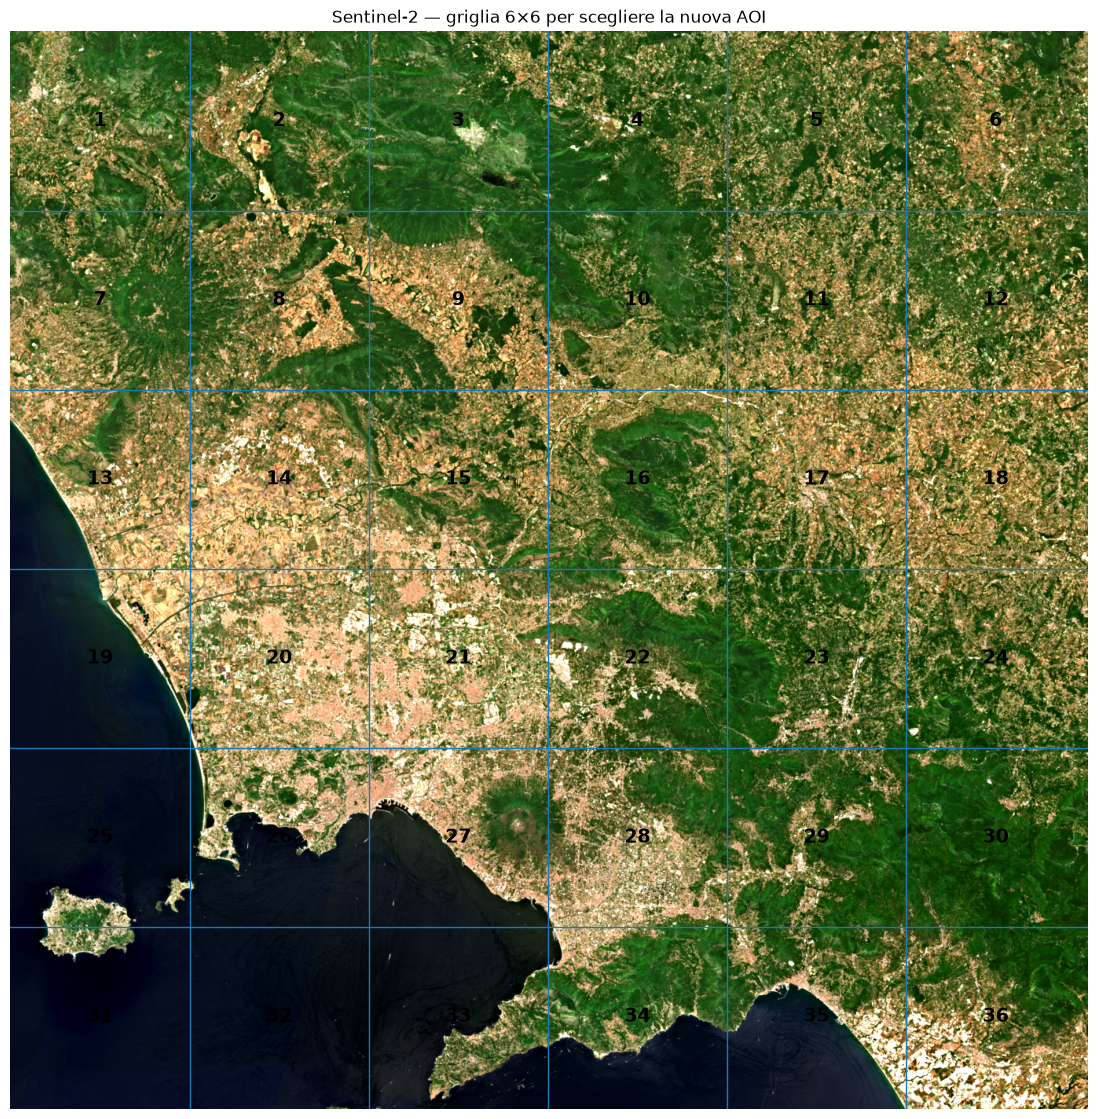

In [82]:
# Dividiamo l'immagine in una griglia 6x6
height = rgb_display.shape[1]
width = rgb_display.shape[2]

rows = 6
cols = 6

block_h = height // rows
block_w = width // cols

fig, ax = plt.subplots(figsize=(14, 14))

ax.imshow(np.moveaxis(rgb_display, 0, -1))

# Disegniamo la griglia
for i in range(1, rows):
    ax.axhline(i * block_h, linewidth=1)

for j in range(1, cols):
    ax.axvline(j * block_w, linewidth=1)

# Numeriamo i blocchi
n = 1

for i in range(rows):
    for j in range(cols):

        x = j * block_w + block_w / 2
        y = i * block_h + block_h / 2

        ax.text(
            x,
            y,
            str(n),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

        n += 1

ax.set_title("Sentinel-2 — griglia 6×6 per scegliere la nuova AOI")
ax.axis("off")

plt.show()

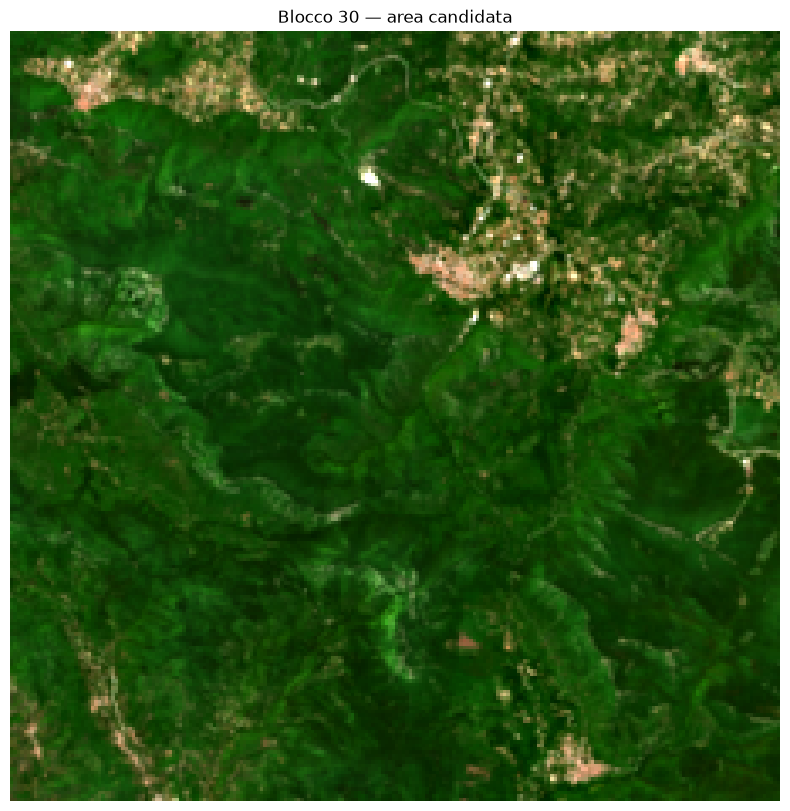

Blocco: 30
Riga: 5
Colonna: 6


In [83]:
# Numero del blocco scelto
selected_block = 30

rows = 6
cols = 6

height = rgb_display.shape[1]
width = rgb_display.shape[2]

block_h = height // rows
block_w = width // cols

# Convertiamo numero blocco -> riga e colonna
index = selected_block - 1

row = index // cols
col = index % cols

# Estraiamo il blocco
block_30 = rgb_display[
    :,
    row * block_h : (row + 1) * block_h,
    col * block_w : (col + 1) * block_w
]

plt.figure(figsize=(10, 10))

plt.imshow(np.moveaxis(block_30, 0, -1))

plt.title(f"Blocco {selected_block} — area candidata")

plt.axis("off")

plt.show()

print("Blocco:", selected_block)
print("Riga:", row + 1)
print("Colonna:", col + 1)

In [84]:
import geopandas as gpd
from shapely.geometry import box

# Numero del blocco scelto
selected_block = 30

rows = 6
cols = 6

height = rgb_display.shape[1]
width = rgb_display.shape[2]

block_h = height // rows
block_w = width // cols

# Convertiamo il numero del blocco in riga e colonna
index = selected_block - 1
row = index // cols
col = index % cols

# Coordinate del blocco nell'immagine ridotta
x1 = col * block_w
y1 = row * block_h

x2 = (col + 1) * block_w
y2 = (row + 1) * block_h

print("Blocco 30:")
print("x:", x1, "->", x2)
print("y:", y1, "->", y2)

Blocco 30:
x: 1140 -> 1368
y: 912 -> 1140


In [85]:
# Dimensioni del blocco 30
block_width = x2 - x1
block_height = y2 - y1

# Prendiamo il 50% centrale del blocco
margin_x = int(block_width * 0.25)
margin_y = int(block_height * 0.25)

aoi_x1 = x1 + margin_x
aoi_x2 = x2 - margin_x

aoi_y1 = y1 + margin_y
aoi_y2 = y2 - margin_y

print("Nuova AOI:")
print("x:", aoi_x1, "->", aoi_x2)
print("y:", aoi_y1, "->", aoi_y2)

Nuova AOI:
x: 1197 -> 1311
y: 969 -> 1083


In [87]:
# ============================================
# STEP 28 — Coordinate reali del blocco 30
# ============================================

import rasterio
from rasterio.windows import Window
from rasterio.windows import bounds
from shapely.geometry import box
import geopandas as gpd

item = items[0]

# Usiamo l'asset RGB della scena del 5 giugno
visual_url = item.assets["visual"].href

with rasterio.open(visual_url) as src:

    # Dimensioni del raster originale
    raster_width = src.width
    raster_height = src.height

    print("Raster originale:")
    print("Width :", raster_width)
    print("Height:", raster_height)
    print("CRS   :", src.crs)

    # Il nostro blocco 30 appartiene alla griglia 6x6
    rows = 6
    cols = 6

    # Coordinate del blocco 30 nella griglia
    index = 30 - 1
    row = index // cols
    col = index % cols

    # Dimensione di un blocco
    block_width = raster_width / cols
    block_height = raster_height / rows

    # Coordinate pixel del blocco 30
    block_x1 = int(col * block_width)
    block_x2 = int((col + 1) * block_width)

    block_y1 = int(row * block_height)
    block_y2 = int((row + 1) * block_height)

    print("\nBlocco 30:")
    print("Riga:", row + 1)
    print("Colonna:", col + 1)
    print("Pixel X:", block_x1, "->", block_x2)
    print("Pixel Y:", block_y1, "->", block_y2)

    # Prendiamo il 50% centrale del blocco
    margin_x = int((block_x2 - block_x1) * 0.25)
    margin_y = int((block_y2 - block_y1) * 0.25)

    aoi_x1 = block_x1 + margin_x
    aoi_x2 = block_x2 - margin_x

    aoi_y1 = block_y1 + margin_y
    aoi_y2 = block_y2 - margin_y

    # Convertiamo i pixel in coordinate geografiche UTM
    left, bottom, right, top = bounds(
        Window(
            aoi_x1,
            aoi_y1,
            aoi_x2 - aoi_x1,
            aoi_y2 - aoi_y1
        ),
        src.transform
    )

    print("\nCoordinate UTM:")
    print("Left  :", left)
    print("Bottom:", bottom)
    print("Right :", right)
    print("Top   :", top)

    # Creiamo il poligono
    aoi_polygon = box(
        left,
        bottom,
        right,
        top
    )

    # GeoDataFrame nella CRS Sentinel-2
    aoi_candidate = gpd.GeoDataFrame(
        {"name": ["Forest Demo v2"]},
        geometry=[aoi_polygon],
        crs=src.crs
    )

# Convertiamo in WGS84
aoi_candidate_wgs84 = aoi_candidate.to_crs("EPSG:4326")

print("\nCoordinate WGS84:")
print(aoi_candidate_wgs84.geometry.iloc[0])

print("\nBounds WGS84:")
print(aoi_candidate_wgs84.total_bounds)

Raster originale:
Width : 10980
Height: 10980
CRS   : EPSG:32633

Blocco 30:
Riga: 5
Colonna: 6
Pixel X: 9150 -> 10980
Pixel Y: 7320 -> 9150

Coordinate UTM:
Left  : 496030.0
Bottom: 4513090.0
Right : 505190.0
Top   : 4522250.0

Coordinate WGS84:
POLYGON ((15.061496702421053 40.76876393249144, 15.06157293276328 40.85128208254603, 14.952900853374713 40.851288899950106, 14.952959164470993 40.76877073020546, 15.061496702421053 40.76876393249144))

Bounds WGS84:
[14.95290085 40.76876393 15.06157293 40.8512889 ]


In [88]:
# ============================================
# STEP 29 — Controllo SCL della nuova AOI
# ============================================

import numpy as np
import rasterio
from rasterio.mask import mask
from collections import Counter

scl_url = item.assets["scl"].href

geometry_candidate = (
    aoi_candidate_wgs84
    .to_crs(aoi_candidate.crs)
    .geometry.iloc[0]
    .__geo_interface__
)

with rasterio.open(scl_url) as src_scl:

    scl_aoi, scl_transform = mask(
        src_scl,
        [geometry_candidate],
        crop=True
    )

scl_values = scl_aoi[0]

# Conta tutte le classi
values, counts = np.unique(
    scl_values,
    return_counts=True
)

total_pixels = counts.sum()

print("Classi SCL nella nuova AOI:\n")

for value, count in zip(values, counts):

    percentage = count / total_pixels * 100

    print(
        f"Classe {int(value):2d}: "
        f"{int(count):5d} pixel "
        f"({percentage:5.1f}%)"
    )

Classi SCL nella nuova AOI:

Classe  0:   459 pixel (  0.2%)
Classe  4: 206485 pixel ( 98.0%)
Classe  5:  3736 pixel (  1.8%)
Classe  7:     1 pixel (  0.0%)


In [90]:
# ============================================
# STEP 30 — NDVI della Forest Demo v2
# ============================================

red_url = item.assets["red"].href
nir_url = item.assets["nir"].href

with rasterio.open(red_url) as src_red:

    geometry = (
        aoi_candidate_wgs84
        .to_crs(src_red.crs)
        .geometry.iloc[0]
        .__geo_interface__
    )

    red_aoi, red_transform = mask(
        src_red,
        [geometry],
        crop=True
    )

with rasterio.open(nir_url) as src_nir:

    nir_aoi, _ = mask(
        src_nir,
        [geometry],
        crop=True
    )

red = red_aoi[0].astype("float32")
nir = nir_aoi[0].astype("float32")

denominator = nir + red

ndvi = np.full(
    red.shape,
    np.nan,
    dtype="float32"
)

valid = denominator != 0

ndvi[valid] = (
    (nir[valid] - red[valid])
    / denominator[valid]
)

# Statistiche preliminari
valid_ndvi = ndvi[np.isfinite(ndvi)]

print("NDVI Forest Demo v2 — 2025-06-05")
print("-----------------------------------")
print("Pixel validi:", len(valid_ndvi))
print("NDVI minimo :", np.min(valid_ndvi))
print("NDVI massimo:", np.max(valid_ndvi))
print("NDVI medio  :", np.mean(valid_ndvi))
print("NDVI mediano:", np.median(valid_ndvi))

NDVI Forest Demo v2 — 2025-06-05
-----------------------------------
Pixel validi: 839056
NDVI minimo : -0.24510396
NDVI massimo: 0.9995804
NDVI medio  : 0.8816077
NDVI mediano: 0.92469877


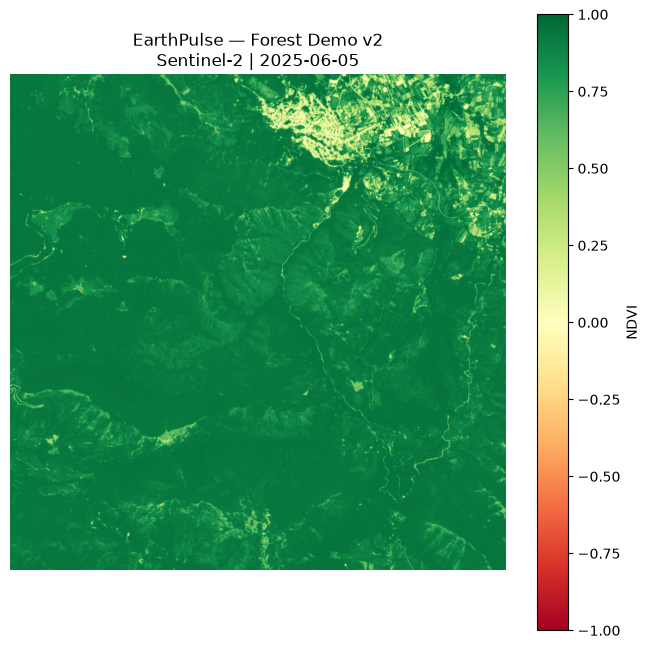

In [91]:
# ============================================
# STEP 31 — Mappa NDVI
# ============================================

plt.figure(figsize=(8, 8))

im = plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    im,
    label="NDVI"
)

plt.title(
    "EarthPulse — Forest Demo v2\n"
    "Sentinel-2 | 2025-06-05"
)

plt.axis("off")

plt.show()

In [92]:
# ============================================
# STEP 32 — Salvataggio Forest Demo v2
# ============================================

from pathlib import Path

# Cartella AOI
aoi_dir = Path("../data/aoi")
aoi_dir.mkdir(parents=True, exist_ok=True)

# Percorso del nuovo GeoJSON
output_path = aoi_dir / "forest_demo_v2.geojson"

# Salviamo in WGS84
aoi_candidate_wgs84.to_file(
    output_path,
    driver="GeoJSON"
)

print("AOI salvata correttamente:")
print(output_path.resolve())

AOI salvata correttamente:
C:\Users\giovm\OneDrive\Desktop\EarthPulse\data\aoi\forest_demo_v2.geojson


In [94]:
# ============================================
# STEP 33 — Verifica GeoJSON
# ============================================

forest_demo = gpd.read_file(
    output_path
)

print(forest_demo)

print("\nCRS:")
print(forest_demo.crs)

print("\nBounds:")
print(forest_demo.total_bounds)

             name                                           geometry
0  Forest Demo v2  POLYGON ((15.0615 40.76876, 15.06157 40.85128,...

CRS:
EPSG:4326

Bounds:
[14.95290085 40.76876393 15.06157293 40.8512889 ]


In [95]:
# ============================================
# STEP 34 — AOI Forest Demo 1 km × 1 km
# ============================================

from shapely.geometry import box

# Centro dell'AOI candidata in UTM
candidate_utm = aoi_candidate

centroid = candidate_utm.geometry.iloc[0].centroid

center_x = centroid.x
center_y = centroid.y

# 1 km x 1 km
half_size = 500

forest_1km_polygon = box(
    center_x - half_size,
    center_y - half_size,
    center_x + half_size,
    center_y + half_size
)

forest_1km = gpd.GeoDataFrame(
    {"name": ["Forest Demo"]},
    geometry=[forest_1km_polygon],
    crs=candidate_utm.crs
)

# Convertiamo in WGS84
forest_1km_wgs84 = forest_1km.to_crs("EPSG:4326")

print("Forest Demo 1 km × 1 km")
print("------------------------")

print("\nCentro UTM:")
print(center_x, center_y)

print("\nBounds WGS84:")
print(forest_1km_wgs84.total_bounds)

print("\nArea:")
print(forest_1km.area.iloc[0] / 1_000_000, "km²")

Forest Demo 1 km × 1 km
------------------------

Centro UTM:
500610.0 4517670.0

Bounds WGS84:
[15.00130412 40.80553454 15.01316151 40.81454382]

Area:
1.0 km²


In [96]:
# ============================================
# STEP 35 — Salvataggio Forest Demo definitiva
# ============================================

final_aoi_path = aoi_dir / "forest_demo.geojson"

forest_1km_wgs84.to_file(
    final_aoi_path,
    driver="GeoJSON"
)

print("Forest Demo definitiva salvata:")
print(final_aoi_path.resolve())

Forest Demo definitiva salvata:
C:\Users\giovm\OneDrive\Desktop\EarthPulse\data\aoi\forest_demo.geojson


In [97]:
# ============================================
# STEP 36 — Caricamento Forest Demo definitiva
# ============================================

import geopandas as gpd

forest_demo = gpd.read_file(
    "../data/aoi/forest_demo.geojson"
)

print("Forest Demo caricata correttamente")
print("----------------------------------")

print("CRS:", forest_demo.crs)
print("Area:", forest_demo.to_crs("EPSG:32633").area.iloc[0] / 1_000_000, "km²")
print("Bounds:", forest_demo.total_bounds)

forest_demo

Forest Demo caricata correttamente
----------------------------------
CRS: EPSG:4326
Area: 1.0000000000005238 km²
Bounds: [15.00130412 40.80553454 15.01316151 40.81454382]


,name,geometry
0,Forest Demo,"POLYGON ((15.01316 40.80553, 15.01316 40.81454..."


In [98]:
# ============================================
# STEP 37 — Ricerca Sentinel-2 Forest Demo
# ============================================

from pystac_client import Client

catalog = Client.open(
    "https://earth-search.aws.element84.com/v1"
)

forest_geometry = forest_demo.geometry.iloc[0].__geo_interface__

search_forest = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=forest_geometry,
    datetime="2025-06-01/2025-09-01",
    query={
        "eo:cloud_cover": {
            "lt": 20
        }
    }
)

forest_items = list(search_forest.items())

print("Scene Sentinel-2 trovate:", len(forest_items))

Scene Sentinel-2 trovate: 41


In [99]:
# ============================================
# STEP 38 — Elenco scene Forest Demo
# ============================================

forest_items = sorted(
    forest_items,
    key=lambda item: item.datetime
)

for item in forest_items:

    print(
        item.datetime.strftime("%Y-%m-%d"),
        "|",
        f"cloud={item.properties.get('eo:cloud_cover'):.2f}%",
        "|",
        item.id
    )

2025-06-05 | cloud=1.72% | S2C_33TWF_20250605_0_L2A
2025-06-05 | cloud=1.78% | S2C_33TVF_20250605_0_L2A
2025-06-07 | cloud=0.00% | S2A_33TWF_20250607_1_L2A
2025-06-07 | cloud=0.00% | S2A_33TVF_20250607_0_L2A
2025-06-07 | cloud=0.00% | S2A_33TWF_20250607_2_L2A
2025-06-07 | cloud=0.01% | S2A_33TVF_20250607_1_L2A
2025-06-10 | cloud=1.03% | S2B_33TWF_20250610_0_L2A
2025-06-10 | cloud=2.47% | S2B_33TVF_20250610_0_L2A
2025-06-15 | cloud=0.01% | S2C_33TWF_20250615_0_L2A
2025-06-15 | cloud=0.58% | S2C_33TVF_20250615_0_L2A
2025-06-17 | cloud=12.62% | S2A_33TVF_20250617_0_L2A
2025-06-20 | cloud=3.55% | S2B_33TWF_20250620_0_L2A
2025-06-20 | cloud=1.51% | S2B_33TVF_20250620_1_L2A
2025-06-25 | cloud=0.90% | S2C_33TWF_20250625_0_L2A
2025-06-25 | cloud=0.96% | S2C_33TVF_20250625_0_L2A
2025-06-27 | cloud=0.31% | S2A_33TWF_20250627_1_L2A
2025-06-27 | cloud=0.27% | S2A_33TVF_20250627_0_L2A
2025-06-30 | cloud=1.67% | S2B_33TWF_20250630_0_L2A
2025-06-30 | cloud=1.19% | S2B_33TVF_20250630_0_L2A
2025-07-05 

In [100]:
# ============================================
# STEP 39 — Test NDVI Forest Demo
# ============================================

test_item = forest_items[0]

print("Scena selezionata:")
print(test_item.id)
print(test_item.datetime)

print("\nAsset disponibili:")
print(list(test_item.assets.keys()))

Scena selezionata:
S2C_33TWF_20250605_0_L2A
2025-06-05 09:59:39.012000+00:00

Asset disponibili:
['aot', 'blue', 'cloud', 'coastal', 'granule_metadata', 'green', 'nir', 'nir08', 'nir09', 'product_metadata', 'red', 'rededge1', 'rededge2', 'rededge3', 'scl', 'snow', 'swir16', 'swir22', 'tileinfo_metadata', 'visual', 'wvp', 'thumbnail', 'aot-jp2', 'blue-jp2', 'coastal-jp2', 'green-jp2', 'nir-jp2', 'nir08-jp2', 'nir09-jp2', 'red-jp2', 'rededge1-jp2', 'rededge2-jp2', 'rededge3-jp2', 'scl-jp2', 'swir16-jp2', 'swir22-jp2', 'visual-jp2', 'wvp-jp2']


In [101]:
# ============================================
# STEP 40 — NDVI + SCL sulla nuova AOI
# ============================================

result_test = calculate_ndvi_for_item(
    test_item,
    forest_demo
)

print("Risultato:")
print("--------------------------------")

for key, value in result_test.items():
    print(f"{key}: {value}")

Risultato:
--------------------------------
date: 2025-06-05 09:59:39.012000+00:00
item_id: S2C_33TWF_20250605_0_L2A
cloud_cover: 1.724832
ndvi_mean: 0.9000828266143799
ndvi_median: 0.9080096483230591
valid_pixels: 10000
valid_percentage: 97.06853038245


In [102]:
# STEP 41 - Calcolo NDVI per tutte le scene Forest Demo

results = []

for i, item in enumerate(forest_items, start=1):

    print(
        f"[{i}/{len(forest_items)}] "
        f"{item.datetime.strftime('%Y-%m-%d')} | "
        f"{item.id}"
    )

    try:
        result = calculate_ndvi_for_item(
            item,
            forest_demo
        )

        results.append(result)

    except Exception as e:
        print(f"   ERRORE: {e}")


forest_ndvi_timeseries = pd.DataFrame(results)

print("\n--------------------------------")
print("Elaborazione completata")
print("Scene elaborate:", len(forest_ndvi_timeseries))
print("--------------------------------")

forest_ndvi_timeseries.head()

[1/41] 2025-06-05 | S2C_33TWF_20250605_0_L2A
[2/41] 2025-06-05 | S2C_33TVF_20250605_0_L2A
[3/41] 2025-06-07 | S2A_33TWF_20250607_1_L2A
[4/41] 2025-06-07 | S2A_33TVF_20250607_0_L2A
[5/41] 2025-06-07 | S2A_33TWF_20250607_2_L2A
[6/41] 2025-06-07 | S2A_33TVF_20250607_1_L2A
[7/41] 2025-06-10 | S2B_33TWF_20250610_0_L2A
[8/41] 2025-06-10 | S2B_33TVF_20250610_0_L2A
[9/41] 2025-06-15 | S2C_33TWF_20250615_0_L2A
[10/41] 2025-06-15 | S2C_33TVF_20250615_0_L2A
[11/41] 2025-06-17 | S2A_33TVF_20250617_0_L2A
[12/41] 2025-06-20 | S2B_33TWF_20250620_0_L2A
[13/41] 2025-06-20 | S2B_33TVF_20250620_1_L2A
[14/41] 2025-06-25 | S2C_33TWF_20250625_0_L2A
[15/41] 2025-06-25 | S2C_33TVF_20250625_0_L2A
[16/41] 2025-06-27 | S2A_33TWF_20250627_1_L2A
[17/41] 2025-06-27 | S2A_33TVF_20250627_0_L2A
[18/41] 2025-06-30 | S2B_33TWF_20250630_0_L2A
[19/41] 2025-06-30 | S2B_33TVF_20250630_0_L2A
[20/41] 2025-07-05 | S2C_33TWF_20250705_0_L2A
[21/41] 2025-07-05 | S2C_33TVF_20250705_0_L2A
[22/41] 2025-07-15 | S2C_33TWF_20250715_0_L

,date,item_id,cloud_cover,ndvi_mean,ndvi_median,valid_pixels,valid_percentage
0,2025-06-05 09:59:39.012000+00:00,S2C_33TWF_20250605_0_L2A,1.724832,0.900083,0.908010,10000,97.06853
1,2025-06-05 09:59:42.626000+00:00,S2C_33TVF_20250605_0_L2A,1.780369,0.914375,0.922892,10000,97.06853
2,2025-06-07 09:59:34.052000+00:00,S2A_33TWF_20250607_1_L2A,0.004655,0.895497,0.902879,10000,97.06853
3,2025-06-07 09:59:35.869000+00:00,S2A_33TVF_20250607_0_L2A,0.000639,0.903512,0.911317,10000,97.06853
4,2025-06-07 09:59:40.964000+00:00,S2A_33TWF_20250607_2_L2A,0.000990,0.890642,0.897900,10000,97.06853


In [103]:
# STEP 42 - Visualizzazione della serie completa

forest_ndvi_timeseries = forest_ndvi_timeseries.sort_values(
    "date"
).reset_index(drop=True)

display(
    forest_ndvi_timeseries[
        [
            "date",
            "item_id",
            "cloud_cover",
            "ndvi_mean",
            "ndvi_median",
            "valid_pixels",
            "valid_percentage"
        ]
    ]
)

,date,item_id,cloud_cover,ndvi_mean,ndvi_median,valid_pixels,valid_percentage
0,2025-06-05 09:59:39.012000+00:00,S2C_33TWF_20250605_0_L2A,1.724832,0.900083,0.908010,10000,97.068530
1,2025-06-05 09:59:42.626000+00:00,S2C_33TVF_20250605_0_L2A,1.780369,0.914375,0.922892,10000,97.068530
2,2025-06-07 09:59:34.052000+00:00,S2A_33TWF_20250607_1_L2A,0.004655,0.895497,0.902879,10000,97.068530
3,2025-06-07 09:59:35.869000+00:00,S2A_33TVF_20250607_0_L2A,0.000639,0.903512,0.911317,10000,97.068530
4,2025-06-07 09:59:40.964000+00:00,S2A_33TWF_20250607_2_L2A,0.000990,0.890642,0.897900,10000,97.068530
5,2025-06-07 09:59:42.616000+00:00,S2A_33TVF_20250607_1_L2A,0.008523,0.907688,0.915691,10000,97.068530
6,2025-06-10 09:59:17.036000+00:00,S2B_33TWF_20250610_0_L2A,1.033351,0.881972,0.886842,10000,97.068530
7,2025-06-10 09:59:20.628000+00:00,S2B_33TVF_20250610_0_L2A,2.473024,0.898412,0.904077,10000,97.068530
8,2025-06-15 09:59:37.735000+00:00,S2C_33TWF_20250615_0_L2A,0.012744,0.892814,0.895804,10000,97.068530
9,2025-06-15 09:59:41.347000+00:00,S2C_33TVF_20250615_0_L2A,0.584597,0.922100,0.925800,10000,97.068530


In [104]:
# STEP 43 - Quality Control e selezione di una sola scena per giorno

# Copia della serie originale
forest_clean = forest_ndvi_timeseries.copy()

# -----------------------------------------
# 1. Convertiamo la data in formato date
# -----------------------------------------

forest_clean["date_only"] = (
    pd.to_datetime(forest_clean["date"])
    .dt.date
)

# -----------------------------------------
# 2. Quality Control
# -----------------------------------------

MIN_VALID_PERCENTAGE = 70.0

forest_clean["quality_ok"] = (
    forest_clean["valid_percentage"] >= MIN_VALID_PERCENTAGE
)

print("Scene totali:", len(forest_clean))
print(
    "Scene con qualità sufficiente:",
    forest_clean["quality_ok"].sum()
)
print(
    "Scene scartate:",
    (~forest_clean["quality_ok"]).sum()
)

# -----------------------------------------
# 3. Teniamo solo le scene di buona qualità
# -----------------------------------------

forest_quality = forest_clean[
    forest_clean["quality_ok"]
].copy()

# -----------------------------------------
# 4. Una sola scena per ogni giorno
#
# Se ci sono più scene nello stesso giorno,
# scegliamo quella con più pixel validi.
# -----------------------------------------

forest_daily = (
    forest_quality
    .sort_values(
        ["date_only", "valid_percentage"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset="date_only",
        keep="first"
    )
    .sort_values("date_only")
    .reset_index(drop=True)
)

print("\n--------------------------------")
print("SERIE TEMPORALE PULITA")
print("--------------------------------")

print(
    "Osservazioni finali:",
    len(forest_daily)
)

print(
    "Periodo:",
    forest_daily["date_only"].min(),
    "→",
    forest_daily["date_only"].max()
)

display(
    forest_daily[
        [
            "date_only",
            "item_id",
            "ndvi_mean",
            "ndvi_median",
            "valid_percentage"
        ]
    ]
)

Scene totali: 41
Scene con qualità sufficiente: 36
Scene scartate: 5

--------------------------------
SERIE TEMPORALE PULITA
--------------------------------
Osservazioni finali: 17
Periodo: 2025-06-05 → 2025-08-26


,date_only,item_id,ndvi_mean,ndvi_median,valid_percentage
0,2025-06-05,S2C_33TWF_20250605_0_L2A,0.900083,0.908010,97.068530
1,2025-06-07,S2A_33TWF_20250607_1_L2A,0.895497,0.902879,97.068530
2,2025-06-10,S2B_33TWF_20250610_0_L2A,0.881972,0.886842,97.068530
3,2025-06-15,S2C_33TWF_20250615_0_L2A,0.892814,0.895804,97.068530
4,2025-06-20,S2B_33TWF_20250620_0_L2A,0.874923,0.876533,97.068530
5,2025-06-25,S2C_33TWF_20250625_0_L2A,0.882683,0.884989,97.068530
6,2025-06-27,S2A_33TWF_20250627_1_L2A,0.877619,0.880532,97.068530
7,2025-06-30,S2B_33TWF_20250630_0_L2A,0.892263,0.894988,97.068530
8,2025-07-05,S2C_33TWF_20250705_0_L2A,0.873950,0.876289,96.728791
9,2025-07-15,S2C_33TVF_20250715_0_L2A,0.895008,0.917953,89.303048


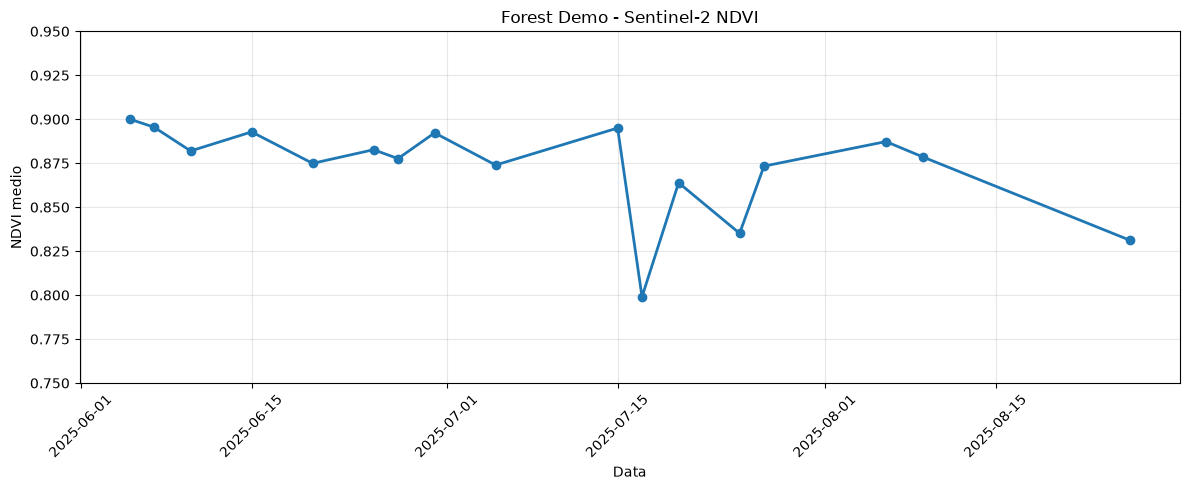

In [105]:
# STEP 44 - Grafico della serie temporale NDVI

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    forest_daily["date_only"],
    forest_daily["ndvi_mean"],
    marker="o",
    linewidth=2
)

plt.title("Forest Demo - Sentinel-2 NDVI")
plt.xlabel("Data")
plt.ylabel("NDVI medio")

plt.ylim(0.75, 0.95)

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [106]:
# STEP 45 - Ricerca Sentinel-2 storica 2023-2025

historical_items = []

years = [2023, 2024, 2025]

for year in years:

    print(f"\nRicerca dati {year}...")

    search = catalog.search(
        collections=["sentinel-2-l2a"],
        intersects=forest_geometry,
        datetime=f"{year}-06-01/{year}-08-31",
        query={"eo:cloud_cover": {"lt": 20}}
    )

    year_items = list(search.items())

    print(
        f"Scene trovate nel {year}:",
        len(year_items)
    )

    historical_items.extend(year_items)

print("\n--------------------------------")
print("RICERCA COMPLETATA")
print("--------------------------------")
print(
    "Scene totali 2023-2025:",
    len(historical_items)
)


Ricerca dati 2023...
Scene trovate nel 2023: 21

Ricerca dati 2024...
Scene trovate nel 2024: 28

Ricerca dati 2025...
Scene trovate nel 2025: 41

--------------------------------
RICERCA COMPLETATA
--------------------------------
Scene totali 2023-2025: 90


In [107]:
# STEP 46 - Distribuzione delle scene per anno

from collections import Counter

year_counts = Counter(
    item.datetime.year
    for item in historical_items
)

print("Scene per anno:")
print("--------------------------------")

for year in sorted(year_counts):
    print(
        year,
        ":",
        year_counts[year]
    )

Scene per anno:
--------------------------------
2023 : 21
2024 : 28
2025 : 41


In [108]:
# STEP 47 - Calcolo NDVI per tutte le scene storiche

historical_results = []

historical_items = sorted(
    historical_items,
    key=lambda item: item.datetime
)

for i, item in enumerate(historical_items, start=1):

    print(
        f"[{i}/{len(historical_items)}] "
        f"{item.datetime.strftime('%Y-%m-%d')} | "
        f"{item.id}"
    )

    try:

        result = calculate_ndvi_for_item(
            item,
            forest_demo
        )

        historical_results.append(result)

    except Exception as e:

        print(
            f"   ERRORE: {e}"
        )


forest_historical = pd.DataFrame(
    historical_results
)

print("\n--------------------------------")
print("ELABORAZIONE STORICA COMPLETATA")
print("--------------------------------")
print(
    "Scene elaborate:",
    len(forest_historical)
)

[1/90] 2023-06-21 | S2B_33TWF_20230621_0_L2A
[2/90] 2023-06-21 | S2B_33TVF_20230621_0_L2A
[3/90] 2023-06-26 | S2A_33TWF_20230626_0_L2A
[4/90] 2023-06-26 | S2A_33TVF_20230626_0_L2A
[5/90] 2023-07-06 | S2A_33TWF_20230706_0_L2A
[6/90] 2023-07-06 | S2A_33TVF_20230706_0_L2A
[7/90] 2023-07-11 | S2B_33TWF_20230711_0_L2A
[8/90] 2023-07-11 | S2B_33TVF_20230711_0_L2A
[9/90] 2023-07-16 | S2A_33TWF_20230716_0_L2A
[10/90] 2023-07-16 | S2A_33TVF_20230716_0_L2A
[11/90] 2023-07-21 | S2B_33TWF_20230721_0_L2A
[12/90] 2023-07-21 | S2B_33TVF_20230721_0_L2A
[13/90] 2023-07-31 | S2B_33TVF_20230731_0_L2A
[14/90] 2023-08-10 | S2B_33TWF_20230810_0_L2A
[15/90] 2023-08-10 | S2B_33TVF_20230810_0_L2A
[16/90] 2023-08-15 | S2A_33TWF_20230815_0_L2A
[17/90] 2023-08-15 | S2A_33TVF_20230815_0_L2A
[18/90] 2023-08-20 | S2B_33TWF_20230820_0_L2A
[19/90] 2023-08-20 | S2B_33TVF_20230820_0_L2A
[20/90] 2023-08-25 | S2A_33TWF_20230825_0_L2A
[21/90] 2023-08-25 | S2A_33TVF_20230825_0_L2A
[22/90] 2024-06-05 | S2B_33TWF_20240605_0_L

In [109]:
# STEP 48 - Quality Control storico e deduplicazione giornaliera

historical_clean = forest_historical.copy()

# -----------------------------------------
# 1. Data senza orario
# -----------------------------------------

historical_clean["date_only"] = (
    pd.to_datetime(historical_clean["date"])
    .dt.date
)

# -----------------------------------------
# 2. Estrazione dell'anno
# -----------------------------------------

historical_clean["year"] = (
    pd.to_datetime(historical_clean["date"]).dt.year
)

# -----------------------------------------
# 3. Quality Control
# -----------------------------------------

MIN_VALID_PERCENTAGE = 70.0

historical_clean["quality_ok"] = (
    historical_clean["valid_percentage"]
    >= MIN_VALID_PERCENTAGE
)

print("Scene totali:", len(historical_clean))

print(
    "Scene di qualità sufficiente:",
    historical_clean["quality_ok"].sum()
)

print(
    "Scene scartate:",
    (~historical_clean["quality_ok"]).sum()
)

# -----------------------------------------
# 4. Manteniamo solo scene di buona qualità
# -----------------------------------------

historical_quality = historical_clean[
    historical_clean["quality_ok"]
].copy()

# -----------------------------------------
# 5. Una sola osservazione per giorno
#
# Se ci sono più tile nello stesso giorno,
# scegliamo quella con maggiore qualità.
# -----------------------------------------

historical_daily = (
    historical_quality
    .sort_values(
        ["date_only", "valid_percentage"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset="date_only",
        keep="first"
    )
    .sort_values("date_only")
    .reset_index(drop=True)
)

print("\n--------------------------------")
print("DATASET STORICO PULITO")
print("--------------------------------")

print(
    "Osservazioni giornaliere:",
    len(historical_daily)
)

print(
    "Periodo:",
    historical_daily["date_only"].min(),
    "→",
    historical_daily["date_only"].max()
)

print("\nOsservazioni per anno:")

print(
    historical_daily.groupby("year")
    .size()
)

display(
    historical_daily[
        [
            "date_only",
            "year",
            "item_id",
            "ndvi_mean",
            "ndvi_median",
            "valid_percentage"
        ]
    ]
)

Scene totali: 90
Scene di qualità sufficiente: 78
Scene scartate: 12

--------------------------------
DATASET STORICO PULITO
--------------------------------
Osservazioni giornaliere: 39
Periodo: 2023-06-21 → 2025-08-26

Osservazioni per anno:
year
2023    10
2024    12
2025    17
dtype: int64


,date_only,year,item_id,ndvi_mean,ndvi_median,valid_percentage
0,2023-06-21,2023,S2B_33TWF_20230621_0_L2A,0.840589,0.844542,97.068530
1,2023-06-26,2023,S2A_33TWF_20230626_0_L2A,0.848826,0.882314,97.010289
2,2023-07-06,2023,S2A_33TWF_20230706_0_L2A,0.893396,0.895663,97.068530
3,2023-07-11,2023,S2B_33TWF_20230711_0_L2A,0.893987,0.896957,97.068530
4,2023-07-16,2023,S2A_33TWF_20230716_0_L2A,0.876090,0.877902,97.068530
5,2023-07-21,2023,S2B_33TWF_20230721_0_L2A,0.873282,0.874282,97.068530
6,2023-08-10,2023,S2B_33TWF_20230810_0_L2A,0.891172,0.892577,97.068530
7,2023-08-15,2023,S2A_33TWF_20230815_0_L2A,0.855577,0.879418,82.731508
8,2023-08-20,2023,S2B_33TVF_20230820_0_L2A,0.860840,0.865144,97.068530
9,2023-08-25,2023,S2A_33TWF_20230825_0_L2A,0.878671,0.881127,97.068530


In [110]:
# STEP 49 - Analisi qualità per anno

quality_by_year = (
    historical_clean
    .groupby("year")
    .agg(
        total_scenes=("item_id", "count"),
        good_scenes=("quality_ok", "sum"),
        mean_valid_percentage=("valid_percentage", "mean"),
        min_valid_percentage=("valid_percentage", "min"),
        max_valid_percentage=("valid_percentage", "max")
    )
)

quality_by_year["good_percentage"] = (
    quality_by_year["good_scenes"]
    / quality_by_year["total_scenes"]
    * 100
)

display(quality_by_year)

,total_scenes,good_scenes,mean_valid_percentage,min_valid_percentage,max_valid_percentage,good_percentage
year,,,,,,
2023,21,20,91.067846,0.000000,97.06853,95.238095
2024,28,22,82.824417,0.000000,97.06853,78.571429
2025,41,36,89.965245,32.809163,97.06853,87.804878


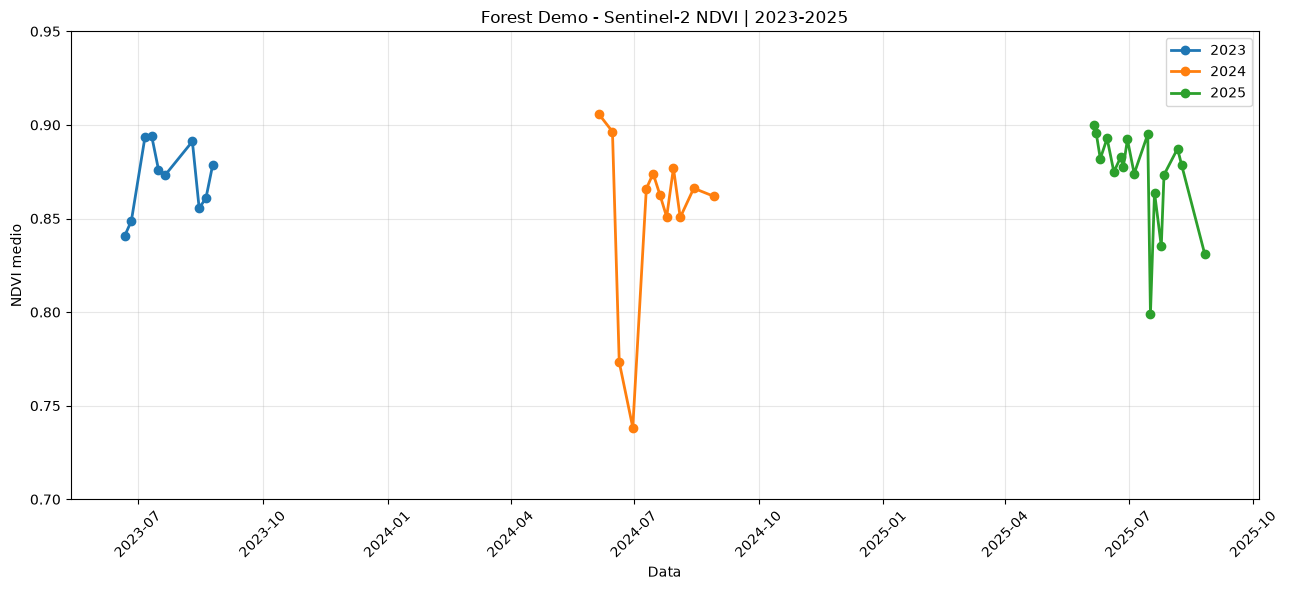

In [112]:
# STEP 50 - Confronto NDVI 2023-2025

plt.figure(figsize=(13, 6))

for year in sorted(historical_daily["year"].unique()):

    year_data = historical_daily[
        historical_daily["year"] == year
    ]

    plt.plot(
        year_data["date_only"],
        year_data["ndvi_mean"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title(
    "Forest Demo - Sentinel-2 NDVI | 2023-2025"
)

plt.xlabel("Data")
plt.ylabel("NDVI medio")

plt.ylim(0.70, 0.95)

plt.grid(True, alpha=0.3)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [113]:
# STEP 51 - Allineamento stagionale tramite giorno dell'anno

historical_daily["day_of_year"] = (
    pd.to_datetime(
        historical_daily["date_only"]
    ).dt.dayofyear
)

display(
    historical_daily[
        [
            "date_only",
            "year",
            "day_of_year",
            "ndvi_mean"
        ]
    ]
)

,date_only,year,day_of_year,ndvi_mean
0,2023-06-21,2023,172,0.840589
1,2023-06-26,2023,177,0.848826
2,2023-07-06,2023,187,0.893396
3,2023-07-11,2023,192,0.893987
4,2023-07-16,2023,197,0.876090
5,2023-07-21,2023,202,0.873282
6,2023-08-10,2023,222,0.891172
7,2023-08-15,2023,227,0.855577
8,2023-08-20,2023,232,0.860840
9,2023-08-25,2023,237,0.878671


In [114]:
# STEP 52 - Costruzione del baseline stagionale 2023-2024
# per valutare le osservazioni del 2025

import numpy as np
import pandas as pd

# -----------------------------------------
# 1. Separiamo storico e anno target
# -----------------------------------------

historical_baseline = historical_daily[
    historical_daily["year"].isin([2023, 2024])
].copy()

target_2025 = historical_daily[
    historical_daily["year"] == 2025
].copy()


# -----------------------------------------
# 2. Funzione per costruire il baseline
# -----------------------------------------

WINDOW_DAYS = 10

baseline_results = []

for _, target_row in target_2025.iterrows():

    target_doy = target_row["day_of_year"]

    # Differenza circolare tra giorni dell'anno
    # Gestisce anche eventuali passaggi vicino a Capodanno.
    doy_difference = np.abs(
        historical_baseline["day_of_year"]
        - target_doy
    )

    doy_difference = np.minimum(
        doy_difference,
        366 - doy_difference
    )

    nearby = historical_baseline[
        doy_difference <= WINDOW_DAYS
    ].copy()

    historical_values = (
        nearby["ndvi_mean"]
        .dropna()
        .values
    )

    if len(historical_values) == 0:

        baseline_median = np.nan
        baseline_mean = np.nan
        baseline_std = np.nan
        baseline_mad = np.nan

    else:

        baseline_median = np.median(
            historical_values
        )

        baseline_mean = np.mean(
            historical_values
        )

        baseline_std = (
            np.std(
                historical_values,
                ddof=1
            )
            if len(historical_values) > 1
            else np.nan
        )

        # Median Absolute Deviation
        baseline_mad = np.median(
            np.abs(
                historical_values
                - baseline_median
            )
        )

    baseline_results.append({

        "date": target_row["date_only"],

        "day_of_year": target_doy,

        "ndvi_2025": target_row["ndvi_mean"],

        "baseline_median": baseline_median,

        "baseline_mean": baseline_mean,

        "baseline_std": baseline_std,

        "baseline_mad": baseline_mad,

        "historical_observations": len(
            historical_values
        )
    })


baseline_2025 = pd.DataFrame(
    baseline_results
)


# -----------------------------------------
# 3. Calcoliamo l'anomalia
# -----------------------------------------

baseline_2025["ndvi_anomaly"] = (
    baseline_2025["ndvi_2025"]
    - baseline_2025["baseline_median"]
)


baseline_2025["anomaly_percent"] = (
    baseline_2025["ndvi_anomaly"]
    / baseline_2025["baseline_median"]
    * 100
)


# -----------------------------------------
# 4. Visualizziamo il risultato
# -----------------------------------------

display(
    baseline_2025[
        [
            "date",
            "day_of_year",
            "ndvi_2025",
            "baseline_median",
            "historical_observations",
            "ndvi_anomaly",
            "anomaly_percent"
        ]
    ]
)

,date,day_of_year,ndvi_2025,baseline_median,historical_observations,ndvi_anomaly,anomaly_percent
0,2025-06-05,156,0.900083,0.905739,1,-0.005656,-0.624443
1,2025-06-07,158,0.895497,0.901073,2,-0.005577,-0.618876
2,2025-06-10,161,0.881972,0.901073,2,-0.019101,-2.119832
3,2025-06-15,166,0.892814,0.868498,4,0.024316,2.799801
4,2025-06-20,171,0.874923,0.844708,4,0.030216,3.577055
5,2025-06-25,176,0.882683,0.840589,5,0.042094,5.007651
6,2025-06-27,178,0.877619,0.840589,5,0.037030,4.405264
7,2025-06-30,181,0.892263,0.840589,5,0.051674,6.147415
8,2025-07-05,186,0.873950,0.865947,5,0.008003,0.924155
9,2025-07-15,196,0.895008,0.874004,7,0.021004,2.403210


In [115]:
# STEP 53 - Variabilità del baseline storico

baseline_2025["baseline_range_estimate"] = (
    baseline_2025["baseline_std"]
)

# Z-score usando la deviazione standard storica
baseline_2025["z_score"] = (
    baseline_2025["ndvi_anomaly"]
    / baseline_2025["baseline_std"]
)

# Z-score robusto usando MAD
# 1.4826 è il fattore standard per rendere
# la MAD comparabile alla deviazione standard
baseline_2025["robust_z_score"] = (
    baseline_2025["ndvi_anomaly"]
    / (
        baseline_2025["baseline_mad"] * 1.4826
    )
)

display(
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "baseline_std",
            "baseline_mad",
            "ndvi_anomaly",
            "anomaly_percent",
            "z_score",
            "robust_z_score",
            "historical_observations"
        ]
    ]
)

,date,ndvi_2025,baseline_median,baseline_std,baseline_mad,ndvi_anomaly,anomaly_percent,z_score,robust_z_score,historical_observations
0,2025-06-05,0.900083,0.905739,NaN,0.000000,-0.005656,-0.624443,NaN,-inf,1
1,2025-06-07,0.895497,0.901073,0.006598,0.004666,-0.005577,-0.618876,-0.845178,-0.806193,2
2,2025-06-10,0.881972,0.901073,0.006598,0.004666,-0.019101,-2.119832,-2.894983,-2.761449,2
3,2025-06-15,0.892814,0.868498,0.061018,0.032575,0.024316,2.799801,0.398506,0.503488,4
4,2025-06-20,0.874923,0.844708,0.050697,0.027909,0.030216,3.577055,0.596006,0.730227,4
5,2025-06-25,0.882683,0.840589,0.063132,0.055819,0.042094,5.007651,0.666760,0.508644,5
6,2025-06-27,0.877619,0.840589,0.062222,0.052807,0.037030,4.405264,0.595128,0.472978,5
7,2025-06-30,0.892263,0.840589,0.062222,0.052807,0.051674,6.147415,0.830483,0.660027,5
8,2025-07-05,0.873950,0.865947,0.064273,0.027448,0.008003,0.924155,0.124511,0.196650,5
9,2025-07-15,0.895008,0.874004,0.012295,0.008056,0.021004,2.403210,1.708389,1.758476,7


In [116]:
# STEP 54 - Supporto storico disponibile per ogni osservazione 2025

def historical_support(n):
    
    if n < 2:
        return "insufficiente"
    
    elif n < 4:
        return "limitato"
    
    elif n < 6:
        return "buono"
    
    else:
        return "forte"


baseline_2025["historical_support"] = (
    baseline_2025["historical_observations"]
    .apply(historical_support)
)

display(
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "historical_observations",
            "historical_support",
            "anomaly_percent"
        ]
    ]
)

,date,ndvi_2025,baseline_median,historical_observations,historical_support,anomaly_percent
0,2025-06-05,0.900083,0.905739,1,insufficiente,-0.624443
1,2025-06-07,0.895497,0.901073,2,limitato,-0.618876
2,2025-06-10,0.881972,0.901073,2,limitato,-2.119832
3,2025-06-15,0.892814,0.868498,4,buono,2.799801
4,2025-06-20,0.874923,0.844708,4,buono,3.577055
5,2025-06-25,0.882683,0.840589,5,buono,5.007651
6,2025-06-27,0.877619,0.840589,5,buono,4.405264
7,2025-06-30,0.892263,0.840589,5,buono,6.147415
8,2025-07-05,0.873950,0.865947,5,buono,0.924155
9,2025-07-15,0.895008,0.874004,7,forte,2.403210


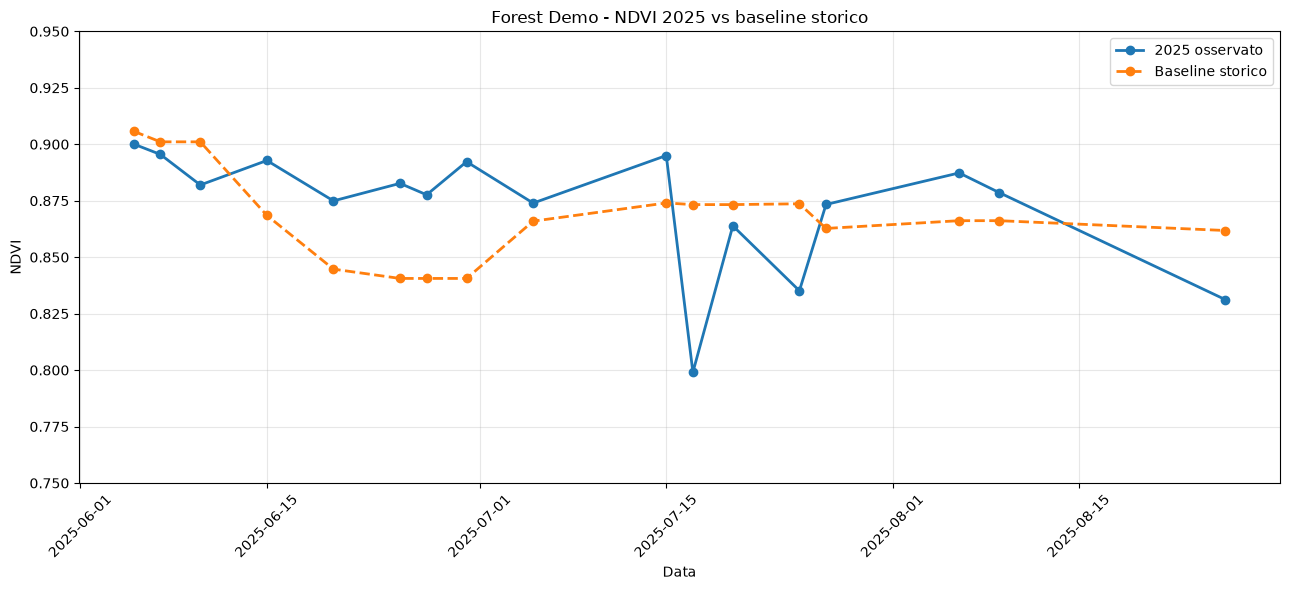

In [117]:
# STEP 55 - NDVI osservato vs baseline storico

plt.figure(figsize=(13, 6))

plt.plot(
    baseline_2025["date"],
    baseline_2025["ndvi_2025"],
    marker="o",
    linewidth=2,
    label="2025 osservato"
)

plt.plot(
    baseline_2025["date"],
    baseline_2025["baseline_median"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Baseline storico"
)

plt.title(
    "Forest Demo - NDVI 2025 vs baseline storico"
)

plt.xlabel("Data")

plt.ylabel("NDVI")

plt.ylim(0.75, 0.95)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

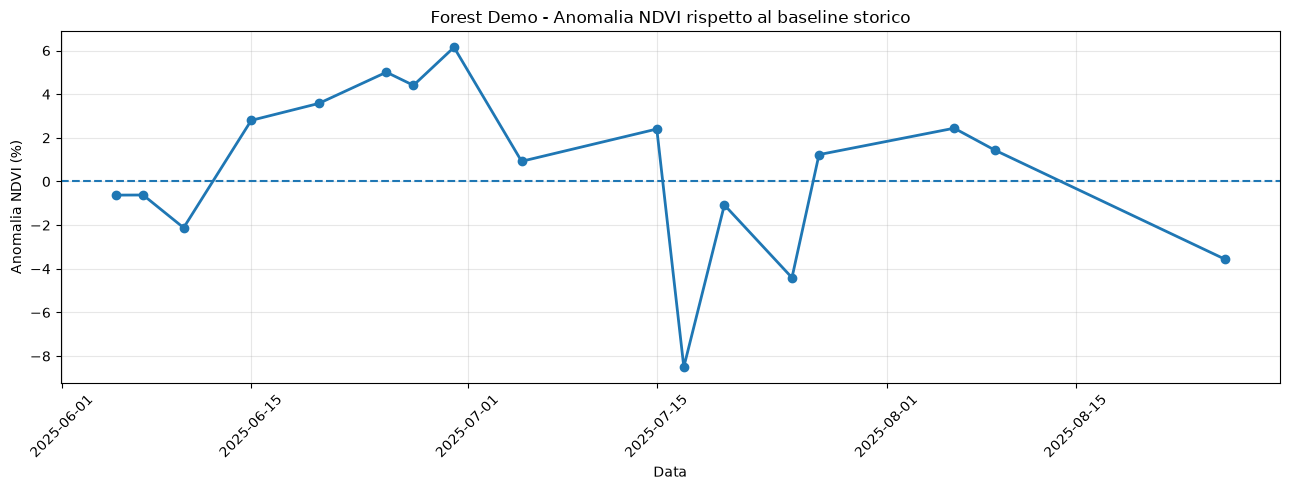

In [118]:
# STEP 56 - Anomalia NDVI rispetto al baseline

plt.figure(figsize=(13, 5))

plt.axhline(
    0,
    linewidth=1.5,
    linestyle="--"
)

plt.plot(
    baseline_2025["date"],
    baseline_2025["anomaly_percent"],
    marker="o",
    linewidth=2
)

plt.title(
    "Forest Demo - Anomalia NDVI rispetto al baseline storico"
)

plt.xlabel("Data")

plt.ylabel("Anomalia NDVI (%)")

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [119]:
# STEP 57 - Analisi della persistenza delle anomalie

baseline_2025 = baseline_2025.sort_values(
    "date"
).reset_index(drop=True)

baseline_2025["negative_anomaly"] = (
    baseline_2025["anomaly_percent"] < 0
)

baseline_2025["positive_anomaly"] = (
    baseline_2025["anomaly_percent"] > 0
)


# Conta quante osservazioni negative consecutive
negative_streak = []

current_streak = 0

for is_negative in baseline_2025["negative_anomaly"]:

    if is_negative:
        current_streak += 1
    else:
        current_streak = 0

    negative_streak.append(current_streak)


baseline_2025["negative_streak"] = negative_streak


display(
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "anomaly_percent",
            "negative_anomaly",
            "negative_streak"
        ]
    ]
)

,date,ndvi_2025,baseline_median,anomaly_percent,negative_anomaly,negative_streak
0,2025-06-05,0.900083,0.905739,-0.624443,True,1
1,2025-06-07,0.895497,0.901073,-0.618876,True,2
2,2025-06-10,0.881972,0.901073,-2.119832,True,3
3,2025-06-15,0.892814,0.868498,2.799801,False,0
4,2025-06-20,0.874923,0.844708,3.577055,False,0
5,2025-06-25,0.882683,0.840589,5.007651,False,0
6,2025-06-27,0.877619,0.840589,4.405264,False,0
7,2025-06-30,0.892263,0.840589,6.147415,False,0
8,2025-07-05,0.873950,0.865947,0.924155,False,0
9,2025-07-15,0.895008,0.874004,2.403210,False,0


In [120]:
# STEP 58 - Osservazioni 2025 più lontane dal baseline

anomaly_summary = (
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "anomaly_percent",
            "historical_observations",
            "historical_support"
        ]
    ]
    .copy()
)

anomaly_summary["absolute_anomaly"] = (
    anomaly_summary["anomaly_percent"]
    .abs()
)

anomaly_summary = (
    anomaly_summary
    .sort_values(
        "absolute_anomaly",
        ascending=False
    )
    .reset_index(drop=True)
)

display(anomaly_summary)

,date,ndvi_2025,baseline_median,anomaly_percent,historical_observations,historical_support,absolute_anomaly
0,2025-07-17,0.799034,0.873282,-8.502254,7,forte,8.502254
1,2025-06-30,0.892263,0.840589,6.147415,5,buono,6.147415
2,2025-06-25,0.882683,0.840589,5.007651,5,buono,5.007651
3,2025-07-25,0.835138,0.873643,-4.407347,6,forte,4.407347
4,2025-06-27,0.877619,0.840589,4.405264,5,buono,4.405264
5,2025-06-20,0.874923,0.844708,3.577055,4,buono,3.577055
6,2025-08-26,0.831191,0.861809,-3.552849,3,limitato,3.552849
7,2025-06-15,0.892814,0.868498,2.799801,4,buono,2.799801
8,2025-08-06,0.887308,0.866164,2.441182,5,buono,2.441182
9,2025-07-15,0.895008,0.874004,2.403210,7,forte,2.403210


In [121]:
# STEP 59 - Statistiche riassuntive delle anomalie 2025

print("========================================")
print("STATISTICHE ANOMALIE 2025")
print("========================================")

print(
    "Numero osservazioni:",
    len(baseline_2025)
)

print(
    "Anomalia media (%):",
    round(
        baseline_2025["anomaly_percent"].mean(),
        2
    )
)

print(
    "Anomalia mediana (%):",
    round(
        baseline_2025["anomaly_percent"].median(),
        2
    )
)

print(
    "Anomalia minima (%):",
    round(
        baseline_2025["anomaly_percent"].min(),
        2
    )
)

print(
    "Anomalia massima (%):",
    round(
        baseline_2025["anomaly_percent"].max(),
        2
    )
)

print(
    "Osservazioni sotto baseline:",
    (
        baseline_2025["anomaly_percent"] < 0
    ).sum()
)

print(
    "Osservazioni sopra baseline:",
    (
        baseline_2025["anomaly_percent"] > 0
    ).sum()
)

print(
    "Anomalia < -5%:",
    (
        baseline_2025["anomaly_percent"] < -5
    ).sum()
)

print(
    "Anomalia > +5%:",
    (
        baseline_2025["anomaly_percent"] > 5
    ).sum()
)

STATISTICHE ANOMALIE 2025
Numero osservazioni: 17
Anomalia media (%): 0.56
Anomalia mediana (%): 1.23
Anomalia minima (%): -8.5
Anomalia massima (%): 6.15
Osservazioni sotto baseline: 7
Osservazioni sopra baseline: 10
Anomalia < -5%: 1
Anomalia > +5%: 2


In [122]:
# STEP 60 - Classificazione preliminare dell'anomalia

def classify_anomaly(anomaly_percent):

    if pd.isna(anomaly_percent):
        return "non disponibile"

    if anomaly_percent <= -8:
        return "anomalia negativa marcata"

    elif anomaly_percent <= -5:
        return "sotto baseline"

    elif anomaly_percent < 0:
        return "leggermente sotto baseline"

    elif anomaly_percent >= 5:
        return "sopra baseline"

    else:
        return "vicino al baseline"


baseline_2025["anomaly_class"] = (
    baseline_2025["anomaly_percent"]
    .apply(classify_anomaly)
)

display(
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "anomaly_percent",
            "anomaly_class",
            "historical_support"
        ]
    ]
)

,date,ndvi_2025,baseline_median,anomaly_percent,anomaly_class,historical_support
0,2025-06-05,0.900083,0.905739,-0.624443,leggermente sotto baseline,insufficiente
1,2025-06-07,0.895497,0.901073,-0.618876,leggermente sotto baseline,limitato
2,2025-06-10,0.881972,0.901073,-2.119832,leggermente sotto baseline,limitato
3,2025-06-15,0.892814,0.868498,2.799801,vicino al baseline,buono
4,2025-06-20,0.874923,0.844708,3.577055,vicino al baseline,buono
5,2025-06-25,0.882683,0.840589,5.007651,sopra baseline,buono
6,2025-06-27,0.877619,0.840589,4.405264,vicino al baseline,buono
7,2025-06-30,0.892263,0.840589,6.147415,sopra baseline,buono
8,2025-07-05,0.873950,0.865947,0.924155,vicino al baseline,buono
9,2025-07-15,0.895008,0.874004,2.403210,vicino al baseline,forte


In [123]:
# STEP 61 - Individuazione delle anomalie negative significative

NEGATIVE_THRESHOLD = -5.0

baseline_2025["negative_significant"] = (
    baseline_2025["anomaly_percent"]
    <= NEGATIVE_THRESHOLD
)

display(
    baseline_2025[
        [
            "date",
            "anomaly_percent",
            "negative_significant",
            "negative_streak"
        ]
    ]
)

,date,anomaly_percent,negative_significant,negative_streak
0,2025-06-05,-0.624443,False,1
1,2025-06-07,-0.618876,False,2
2,2025-06-10,-2.119832,False,3
3,2025-06-15,2.799801,False,0
4,2025-06-20,3.577055,False,0
5,2025-06-25,5.007651,False,0
6,2025-06-27,4.405264,False,0
7,2025-06-30,6.147415,False,0
8,2025-07-05,0.924155,False,0
9,2025-07-15,2.403210,False,0


In [124]:
# STEP 62 - Persistenza delle anomalie negative significative

significant_streak = []

current_streak = 0

for is_negative in baseline_2025["negative_significant"]:

    if is_negative:
        current_streak += 1
    else:
        current_streak = 0

    significant_streak.append(
        current_streak
    )


baseline_2025["significant_negative_streak"] = (
    significant_streak
)

baseline_2025["persistent_negative"] = (
    baseline_2025["significant_negative_streak"] >= 2
)

display(
    baseline_2025[
        [
            "date",
            "anomaly_percent",
            "negative_significant",
            "significant_negative_streak",
            "persistent_negative"
        ]
    ]
)

,date,anomaly_percent,negative_significant,significant_negative_streak,persistent_negative
0,2025-06-05,-0.624443,False,0,False
1,2025-06-07,-0.618876,False,0,False
2,2025-06-10,-2.119832,False,0,False
3,2025-06-15,2.799801,False,0,False
4,2025-06-20,3.577055,False,0,False
5,2025-06-25,5.007651,False,0,False
6,2025-06-27,4.405264,False,0,False
7,2025-06-30,6.147415,False,0,False
8,2025-07-05,0.924155,False,0,False
9,2025-07-15,2.403210,False,0,False


In [125]:
# STEP 63 - Stato operativo di ogni osservazione

def determine_status(row):

    anomaly = row["anomaly_percent"]
    support = row["historical_support"]
    persistent = row["persistent_negative"]

    if pd.isna(anomaly):
        return "dati insufficienti"

    if support == "insufficiente":
        return "baseline poco supportato"

    if persistent:
        return "anomalia negativa persistente"

    if anomaly <= -8:
        return "anomalia negativa isolata"

    if anomaly <= -5:
        return "sotto baseline"

    if anomaly < 0:
        return "leggermente sotto baseline"

    if anomaly >= 5:
        return "sopra baseline"

    return "entro la variabilità del baseline"


baseline_2025["status"] = (
    baseline_2025
    .apply(determine_status, axis=1)
)

display(
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "anomaly_percent",
            "historical_support",
            "status"
        ]
    ]
)

,date,ndvi_2025,baseline_median,anomaly_percent,historical_support,status
0,2025-06-05,0.900083,0.905739,-0.624443,insufficiente,baseline poco supportato
1,2025-06-07,0.895497,0.901073,-0.618876,limitato,leggermente sotto baseline
2,2025-06-10,0.881972,0.901073,-2.119832,limitato,leggermente sotto baseline
3,2025-06-15,0.892814,0.868498,2.799801,buono,entro la variabilità del baseline
4,2025-06-20,0.874923,0.844708,3.577055,buono,entro la variabilità del baseline
5,2025-06-25,0.882683,0.840589,5.007651,buono,sopra baseline
6,2025-06-27,0.877619,0.840589,4.405264,buono,entro la variabilità del baseline
7,2025-06-30,0.892263,0.840589,6.147415,buono,sopra baseline
8,2025-07-05,0.873950,0.865947,0.924155,buono,entro la variabilità del baseline
9,2025-07-15,0.895008,0.874004,2.403210,forte,entro la variabilità del baseline


In [126]:
# STEP 64 - Riepilogo degli stati 2025

status_counts = (
    baseline_2025["status"]
    .value_counts()
)

print("========================================")
print("EARTHPULSE - STATI FOREST DEMO 2025")
print("========================================")

display(status_counts)

print("\nDettaglio:")

display(
    baseline_2025[
        [
            "date",
            "ndvi_2025",
            "baseline_median",
            "anomaly_percent",
            "historical_support",
            "negative_streak",
            "status"
        ]
    ]
)

EARTHPULSE - STATI FOREST DEMO 2025


status
entro la variabilità del baseline    8
leggermente sotto baseline           5
sopra baseline                       2
baseline poco supportato             1
anomalia negativa isolata            1
Name: count, dtype: int64


Dettaglio:


,date,ndvi_2025,baseline_median,anomaly_percent,historical_support,negative_streak,status
0,2025-06-05,0.900083,0.905739,-0.624443,insufficiente,1,baseline poco supportato
1,2025-06-07,0.895497,0.901073,-0.618876,limitato,2,leggermente sotto baseline
2,2025-06-10,0.881972,0.901073,-2.119832,limitato,3,leggermente sotto baseline
3,2025-06-15,0.892814,0.868498,2.799801,buono,0,entro la variabilità del baseline
4,2025-06-20,0.874923,0.844708,3.577055,buono,0,entro la variabilità del baseline
5,2025-06-25,0.882683,0.840589,5.007651,buono,0,sopra baseline
6,2025-06-27,0.877619,0.840589,4.405264,buono,0,entro la variabilità del baseline
7,2025-06-30,0.892263,0.840589,6.147415,buono,0,sopra baseline
8,2025-07-05,0.873950,0.865947,0.924155,buono,0,entro la variabilità del baseline
9,2025-07-15,0.895008,0.874004,2.403210,forte,0,entro la variabilità del baseline


In [127]:
# STEP 65 - Stato più recente della Forest Demo

latest_observation = (
    baseline_2025
    .sort_values("date")
    .iloc[-1]
)

print("========================================")
print("ULTIMA OSSERVAZIONE FOREST DEMO")
print("========================================")

print(
    "Data:",
    latest_observation["date"]
)

print(
    "NDVI:",
    round(
        latest_observation["ndvi_2025"],
        4
    )
)

print(
    "Baseline:",
    round(
        latest_observation["baseline_median"],
        4
    )
)

print(
    "Anomalia:",
    round(
        latest_observation["anomaly_percent"],
        2
    ),
    "%"
)

print(
    "Supporto storico:",
    latest_observation["historical_support"]
)

print(
    "Stato:",
    latest_observation["status"]
)

ULTIMA OSSERVAZIONE FOREST DEMO
Data: 2025-08-26
NDVI: 0.8312
Baseline: 0.8618
Anomalia: -3.55 %
Supporto storico: limitato
Stato: leggermente sotto baseline


In [128]:
# STEP 66 - Stato generale della Forest Demo

latest = baseline_2025.sort_values("date").iloc[-1]

recent_observations = (
    baseline_2025
    .sort_values("date")
    .tail(3)
)

persistent_recent = (
    recent_observations["negative_significant"]
    .sum()
    >= 2
)

latest_anomaly = latest["anomaly_percent"]

if persistent_recent:

    overall_status = (
        "persistent negative anomaly"
    )

elif latest_anomaly <= -5:

    overall_status = (
        "below historical baseline"
    )

elif latest_anomaly < 0:

    overall_status = (
        "slightly below historical baseline"
    )

else:

    overall_status = (
        "within or above historical baseline"
    )


print("========================================")
print("EARTHPULSE - FOREST DEMO")
print("========================================")

print(
    "Overall status:",
    overall_status
)

print(
    "Latest observation:",
    latest["date"]
)

print(
    "Latest NDVI:",
    round(
        latest["ndvi_2025"],
        4
    )
)

print(
    "Latest anomaly:",
    round(
        latest_anomaly,
        2
    ),
    "%"
)

print(
    "Historical support:",
    latest["historical_support"]
)

EARTHPULSE - FOREST DEMO
Overall status: slightly below historical baseline
Latest observation: 2025-08-26
Latest NDVI: 0.8312
Latest anomaly: -3.55 %
Historical support: limitato


In [129]:
# STEP 67 - Primo dataset strutturato per EarthPulse

latest = (
    baseline_2025
    .sort_values("date")
    .iloc[-1]
)

earthpulse_forest = {

    "place_id": "forest_demo",

    "place_name": "Forest Demo",

    "indicator": "NDVI",

    "satellite": "Sentinel-2",

    "processing_period": {
        "start": str(
            baseline_2025["date"].min()
        ),
        "end": str(
            baseline_2025["date"].max()
        )
    },

    "latest_observation": {

        "date": str(
            latest["date"]
        ),

        "ndvi": round(
            float(
                latest["ndvi_2025"]
            ),
            4
        ),

        "baseline": round(
            float(
                latest["baseline_median"]
            ),
            4
        ),

        "anomaly_percent": round(
            float(
                latest["anomaly_percent"]
            ),
            2
        ),

        "historical_support":
            latest["historical_support"],

        "status":
            latest["status"]
    },

    "methodology": {

        "baseline_years": [
            2023,
            2024
        ],

        "baseline_window_days":
            WINDOW_DAYS,

        "quality_threshold_percent":
            MIN_VALID_PERCENTAGE,

        "index":
            "NDVI = (NIR - RED) / (NIR + RED)"
    }
}


print(
    earthpulse_forest
)

{'place_id': 'forest_demo', 'place_name': 'Forest Demo', 'indicator': 'NDVI', 'satellite': 'Sentinel-2', 'processing_period': {'start': '2025-06-05', 'end': '2025-08-26'}, 'latest_observation': {'date': '2025-08-26', 'ndvi': 0.8312, 'baseline': 0.8618, 'anomaly_percent': -3.55, 'historical_support': 'limitato', 'status': 'leggermente sotto baseline'}, 'methodology': {'baseline_years': [2023, 2024], 'baseline_window_days': 10, 'quality_threshold_percent': 70.0, 'index': 'NDVI = (NIR - RED) / (NIR + RED)'}}


In [130]:
# STEP 68 - Cartelle di output EarthPulse

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
VISUALS_DIR = PROJECT_ROOT / "data" / "visuals"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VISUALS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Processed:", PROCESSED_DIR)
print("Visuals:", VISUALS_DIR)

Project root: c:\Users\giovm\OneDrive\Desktop\EarthPulse
Processed: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\processed
Visuals: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\visuals


In [131]:
# STEP 69 - Esportazione serie temporale NDVI + baseline

timeseries_export = baseline_2025.copy()

timeseries_export["date"] = (
    pd.to_datetime(
        timeseries_export["date"]
    ).dt.strftime("%Y-%m-%d")
)

timeseries_path = (
    PROCESSED_DIR
    / "forest_demo_timeseries.csv"
)

timeseries_export.to_csv(
    timeseries_path,
    index=False
)

print(
    "File salvato:",
    timeseries_path
)

File salvato: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\processed\forest_demo_timeseries.csv


In [132]:
# STEP 70 - Generazione JSON EarthPulse

import json

# -----------------------------------------
# Serie temporale
# -----------------------------------------

timeseries = []

for _, row in baseline_2025.sort_values("date").iterrows():

    timeseries.append({

        "date": str(row["date"]),

        "ndvi": round(
            float(row["ndvi_2025"]),
            4
        ),

        "baseline": round(
            float(row["baseline_median"]),
            4
        ),

        "anomaly_percent": round(
            float(row["anomaly_percent"]),
            2
        ),

        "historical_observations": int(
            row["historical_observations"]
        ),

        "historical_support": str(
            row["historical_support"]
        ),

        "status": str(
            row["status"]
        )
    })


# -----------------------------------------
# Ultima osservazione
# -----------------------------------------

latest = (
    baseline_2025
    .sort_values("date")
    .iloc[-1]
)


# -----------------------------------------
# Struttura principale
# -----------------------------------------

earthpulse_forest = {

    "place_id": "forest_demo",

    "place_name": "Forest Demo",

    "indicator": {
        "name": "NDVI",
        "description": "Normalized Difference Vegetation Index"
    },

    "source": {
        "satellite": "Sentinel-2",
        "product": "Level-2A"
    },

    "latest_observation": {

        "date": str(
            latest["date"]
        ),

        "ndvi": round(
            float(
                latest["ndvi_2025"]
            ),
            4
        ),

        "baseline": round(
            float(
                latest["baseline_median"]
            ),
            4
        ),

        "anomaly_percent": round(
            float(
                latest["anomaly_percent"]
            ),
            2
        ),

        "historical_support": str(
            latest["historical_support"]
        ),

        "status": str(
            latest["status"]
        )
    },

    "methodology": {

        "baseline_years": [
            2023,
            2024
        ],

        "baseline_window_days": int(
            WINDOW_DAYS
        ),

        "quality_threshold_percent": float(
            MIN_VALID_PERCENTAGE
        ),

        "formula":
            "(NIR - RED) / (NIR + RED)"
    },

    "timeseries": timeseries
}


json_path = (
    PROCESSED_DIR
    / "forest_demo.json"
)


with open(
    json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        earthpulse_forest,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "JSON salvato:",
    json_path
)

JSON salvato: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\processed\forest_demo.json


In [133]:
# STEP 71 - Verifica JSON

with open(
    json_path,
    "r",
    encoding="utf-8"
) as f:

    test_json = json.load(f)


print("JSON valido.")

print(
    "Place:",
    test_json["place_name"]
)

print(
    "Satellite:",
    test_json["source"]["satellite"]
)

print(
    "Indicatore:",
    test_json["indicator"]["name"]
)

print(
    "Osservazioni:",
    len(
        test_json["timeseries"]
    )
)

print(
    "Ultima osservazione:",
    test_json["latest_observation"]
)

JSON valido.
Place: Forest Demo
Satellite: Sentinel-2
Indicatore: NDVI
Osservazioni: 17
Ultima osservazione: {'date': '2025-08-26', 'ndvi': 0.8312, 'baseline': 0.8618, 'anomaly_percent': -3.55, 'historical_support': 'limitato', 'status': 'leggermente sotto baseline'}


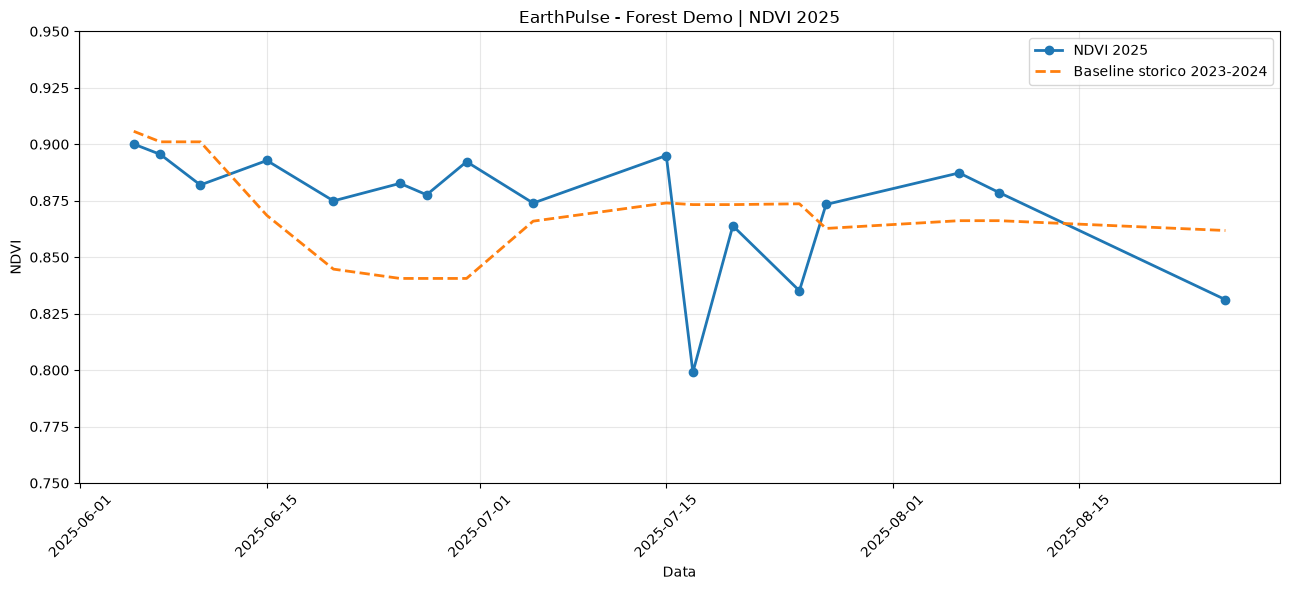

Grafico salvato: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\visuals\forest_demo_ndvi_2025.png


In [134]:
# STEP 72 - Grafico ufficiale EarthPulse

plt.figure(figsize=(13, 6))

plt.plot(
    baseline_2025["date"],
    baseline_2025["ndvi_2025"],
    marker="o",
    linewidth=2,
    label="NDVI 2025"
)

plt.plot(
    baseline_2025["date"],
    baseline_2025["baseline_median"],
    linestyle="--",
    linewidth=2,
    label="Baseline storico 2023-2024"
)

plt.title(
    "EarthPulse - Forest Demo | NDVI 2025"
)

plt.xlabel("Data")

plt.ylabel("NDVI")

plt.ylim(
    0.75,
    0.95
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

timeseries_plot_path = (
    VISUALS_DIR
    / "forest_demo_ndvi_2025.png"
)

plt.savefig(
    timeseries_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "Grafico salvato:",
    timeseries_plot_path
)

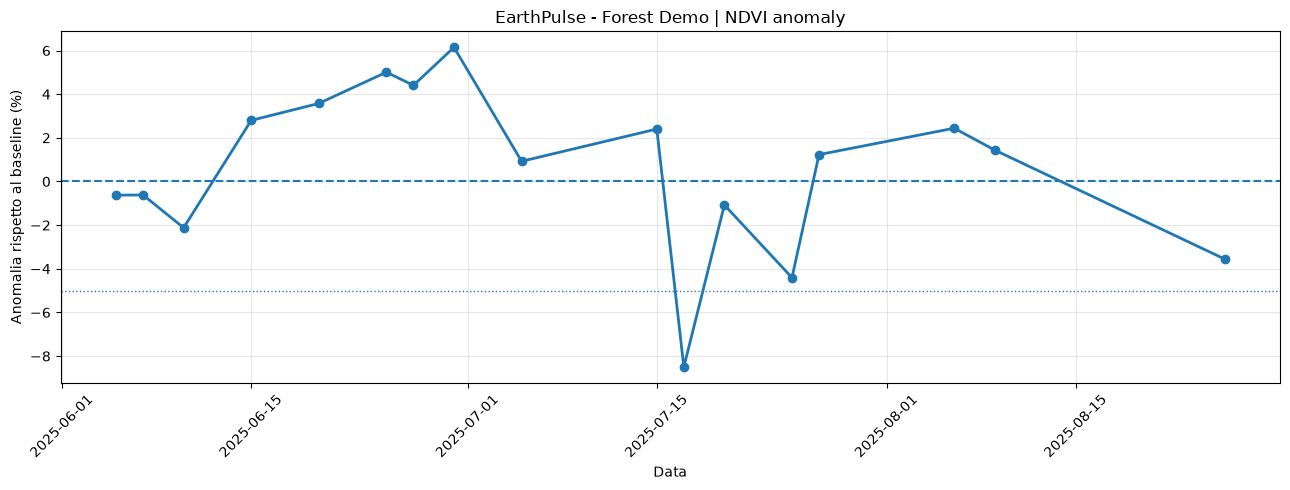

Grafico salvato: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\visuals\forest_demo_ndvi_anomaly.png


In [135]:
# STEP 73 - Grafico ufficiale delle anomalie

plt.figure(figsize=(13, 5))

plt.axhline(
    0,
    linewidth=1.5,
    linestyle="--"
)

plt.axhline(
    -5,
    linewidth=1,
    linestyle=":"
)

plt.plot(
    baseline_2025["date"],
    baseline_2025["anomaly_percent"],
    marker="o",
    linewidth=2
)

plt.title(
    "EarthPulse - Forest Demo | NDVI anomaly"
)

plt.xlabel("Data")

plt.ylabel(
    "Anomalia rispetto al baseline (%)"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

anomaly_plot_path = (
    VISUALS_DIR
    / "forest_demo_ndvi_anomaly.png"
)

plt.savefig(
    anomaly_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "Grafico salvato:",
    anomaly_plot_path
)

In [136]:
# STEP 74 - Report sintetico Forest Demo

latest = (
    baseline_2025
    .sort_values("date")
    .iloc[-1]
)

report = {

    "place_id": "forest_demo",

    "name": "Forest Demo",

    "latest_date": str(
        latest["date"]
    ),

    "indicator": "NDVI",

    "ndvi": round(
        float(latest["ndvi_2025"]),
        4
    ),

    "historical_baseline": round(
        float(latest["baseline_median"]),
        4
    ),

    "anomaly_percent": round(
        float(latest["anomaly_percent"]),
        2
    ),

    "status": str(
        latest["status"]
    ),

    "historical_support": str(
        latest["historical_support"]
    ),

    "data_quality_threshold": (
        f"{MIN_VALID_PERCENTAGE}%"
    ),

    "historical_period": "2023-2024",

    "target_period": "2025",

    "observation_count": int(
        len(baseline_2025)
    )
}


report_path = (
    PROCESSED_DIR
    / "forest_demo_report.json"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "Report salvato:",
    report_path
)

display(
    pd.DataFrame(
        [report]
    )
)

Report salvato: c:\Users\giovm\OneDrive\Desktop\EarthPulse\data\processed\forest_demo_report.json


,place_id,name,latest_date,indicator,ndvi,historical_baseline,anomaly_percent,status,historical_support,data_quality_threshold,historical_period,target_period,observation_count
0,forest_demo,Forest Demo,2025-08-26,NDVI,0.8312,0.8618,-3.55,leggermente sotto baseline,limitato,70.0%,2023-2024,2025,17


In [137]:
# STEP 75 - Preparazione dati per Android

ANDROID_DATA_DIR = (
    PROJECT_ROOT
    / "android"
    / "app"
    / "src"
    / "main"
    / "assets"
)

ANDROID_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

android_json_path = (
    ANDROID_DATA_DIR
    / "forest_demo.json"
)

with open(
    json_path,
    "r",
    encoding="utf-8"
) as source:

    json_content = source.read()


with open(
    android_json_path,
    "w",
    encoding="utf-8"
) as destination:

    destination.write(
        json_content
    )


print(
    "JSON copiato per Android:"
)

print(
    android_json_path
)

JSON copiato per Android:
c:\Users\giovm\OneDrive\Desktop\EarthPulse\android\app\src\main\assets\forest_demo.json
